# GPU Metrics Data Processing & Imputation Notebook

This notebook performs data imputation on GPU utilization metrics from StarRocks, using Spark MLlib linear regression to fill in missing `redfish_power` values based on GPU performance metrics.

---

## 📋 Notebook Structure

### **Setup & Initialization** (Cells 1-5)

- **Cell 1**: Package installation - Installs required Python packages including Spark connectors, StarRocks drivers, visualization libraries, and ML tools
- **Cell 2**: Credential management - Sets up encrypted keyring for secure storage of StarRocks credentials
- **Cell 3**: Database connection validation - Establishes SQLAlchemy connection to StarRocks warehouse to verify credentials
- **Cell 4**: Spark cluster setup - Configures Spark session with Enterprise Gateway (SparkCaster) and initializes StarRocksSparkClient to load source data from `sandbox_finance.capacity_finance_dcgm_metrics_union_raw`
- **Cell 5**: Library imports - Imports core analysis libraries (numpy, pandas, matplotlib, PySpark functions)
- **Cell 6**: Data preparation - Selects relevant columns and prepares DataFrame for analysis

### **Data Imputation Pipeline** (Cells 7-17)

**Purpose**: Use machine learning to impute missing `redfish_power` values based on GPU metrics

- **Cell 7**: Deprecated marker - Points to Cell 8 for the complete pipeline
- **Cell 8**: Complete imputation pipeline (commented/reference) - Shows full end-to-end process: training → imputation → Parquet output
- **Cell 9**: Test upload - Tests StarRocks connection by uploading 1,000 sample rows to verify configuration before full upload
- **Cell 10**: Model 1 training - Simple linear regression using `chip_power` only
- **Cell 11**: Diagnostic plots - QQ plots and predicted vs actual visualizations for all models
- **Cell 12**: Final model training - Retrains best model on 10% data sample for production use
- **Cell 13**: Imputation execution - Applies trained model to predict missing `redfish_power` values
- **Cell 14**: Table check - Verifies target table exists in StarRocks
- **Cell 15**: Table creation - Creates target table if needed
- **Cell 16**: Schema comparison - Compares source and target table schemas
- **Cell 17**: Data joining - Joins imputed data with original full dataset to create complete output

### **Data Upload to StarRocks** (Cells 18-19)

- **Cell 18**: Test upload (1,000 rows) - Validates StarRocks connection and upload configuration with small sample
  - Checks if target table exists, creates it if needed
  - Uploads 1,000 test rows using direct Spark writer
  - Verifies upload success with row count check
  - **Target table**: `sandbox_finance.capacity_finance_dcgm_metrics_union_raw_impute_test`
  
- **Cell 19**: Full data upload - Uploads complete imputed dataset to StarRocks
  - Shows current table status and row count
  - Requires user confirmation before proceeding
  - Step 1: Truncates target table (deletes all existing rows)
  - Step 2: Uploads all imputed data in append mode
  - Verifies final row count matches expected count
  - Reports upload statistics (time, rate, row count)

---

## 🎯 Key Features

- **ML-based Imputation**: Uses Spark MLlib linear regression to predict missing power values
- **Scalable Processing**: Designed for large datasets with Spark 3.5.5 on Enterprise Gateway
- **Secure Credentials**: Encrypted keyring storage for database passwords
- **Data Validation**: Built-in schema comparison and row count verification
- **Safe Uploads**: Test upload before full data load, with user confirmation prompts

---

## �� Quick Start

1. **Setup** (Cells 1-4): Install packages, configure credentials, connect to StarRocks
2. **Load Data** (Cells 5-6): Import libraries and prepare source data
3. **Imputation** (Cells 10-13): Train model and impute missing values
4. **Join Data** (Cell 17): Combine imputed values with full dataset
5. **Test Upload** (Cell 18): Verify StarRocks connection with 1,000 row sample
6. **Full Upload** (Cell 19): Upload complete imputed dataset

---

## 📊 Key Data Assets

### Input Data
- **Source Table**: `sandbox_finance.capacity_finance_dcgm_metrics_union_raw`
- **Parquet Cache**: `/tmp/sdf_complete_imputed.parquet` (intermediate storage)

### Output Data
- **Target Table**: `sandbox_finance.capacity_finance_dcgm_metrics_union_raw_impute_test`
- **Schema**: 21 columns including `datestamp`, `node`, `gpu_util`, `tensor_util`, `chip_power`, `redfish_power` (imputed), and metadata fields

### Features Used for Imputation
- `chip_power` - Primary predictor for `redfish_power`
- `gpu_util` - GPU utilization percentage
- `tensor_util` - Tensor core utilization
- `tensor_tflops` - Tensor FLOPS performance

---

## 🔧 Technical Notes

### StarRocks Connection
- **Host**: `kube-starrocks-warehouse-fe-service.starrocks.svc.cluster.local`
- **HTTP Port**: 8030
- **JDBC Port**: 9030
- **Database**: `sandbox_finance`
- **JDBC URL Format**: `jdbc:mysql://host:port/database` (database must be explicitly specified)

### Upload Configuration
- **Format**: JSON
- **Mode**: Truncate + Append (Cell 19), Append (Cell 18)
- **Timeout**: 3600s (1 hour) for large uploads
- **Verification**: Row count validation after each upload

---

## ⚠️ Important Notes

- Cell 18 must be run successfully before Cell 19
- Cell 19 requires user confirmation as it truncates the target table
- The notebook uses direct Spark `.write.format("starrocks")` instead of `StarRocksSparkClient.db_load()` to ensure correct database targeting
- All imputed `redfish_power` values are marked with a flag for tracking

In [1]:
#install needed packages

import importlib
import subprocess
import sys

def is_module_available(module_name: str) -> bool:
    """Return True if the importable module exists; handles dotted names safely."""
    try:
        return importlib.util.find_spec(module_name) is not None
    except ModuleNotFoundError:
        return False

def install_if_missing(pip_name: str, import_name: str = None):
    """
    Install `pip_name` only if `import_name` (or `pip_name` if None) is not importable.
    Use this to handle cases where pip/distribution names differ from import names.
    """
    import_name = import_name or pip_name
    if not is_module_available(import_name):
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        print(f"{pip_name} already installed.")

# --- Packages for Nessie/Iceberg access ---
# simple 1:1 cases
install_if_missing("keyring", "keyring")
install_if_missing("ipython-secrets", "ipython_secrets")
install_if_missing("pyarrow", "pyarrow")
install_if_missing("fsspec", "fsspec")
install_if_missing("s3fs", "s3fs")
install_if_missing("statsmodels", "statsmodels")
install_if_missing("matplotlib", "matplotlib")
install_if_missing("scikit-learn", "sklearn")
install_if_missing("xgboost", "xgboost")

# special cases
# keyrings.cryptfile installs a plugin under the 'keyrings' package; checking the root avoids ModuleNotFoundError
install_if_missing("keyrings.cryptfile", "keyrings")

# Core viz + scaling pins for Python 3.11.11
install_if_missing("bokeh==3.6.2", "bokeh")
install_if_missing("jupyter_bokeh", "jupyter_bokeh")
install_if_missing("panel==1.5.2", "panel")
install_if_missing("holoviews==1.19.0", "holoviews")
install_if_missing("hvplot==0.10.0", "hvplot")
install_if_missing("datashader==0.16.3", "datashader")
install_if_missing("dask[dataframe]==2024.9.1", "dask")
install_if_missing("distributed==2024.9.1", "distributed")
install_if_missing("reportlab", "reportlab")

install_if_missing("optuna", "optuna")
print("\n✓ All packages installed/verified")

keyring already installed.
ipython-secrets already installed.
pyarrow already installed.
fsspec already installed.
s3fs already installed.
Installing statsmodels ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 65.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
Installing matplotlib ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 217.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 256.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 255.2 MB/s  0:00:00
   ━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [fonttools]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]
scikit-learn already installed.
Installing xgboost ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 792.8 kB/s  0:02:310:00:0100:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.1 MB/s  0:05:27m0:00:0100:08m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
keyrings.cryptfile already installed.
Installing bokeh==3.6.2 ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 64.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [bokeh]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [bokeh]
Installing jupyter_bokeh ...
Defaulting to user installation because normal site-packages is not writeable
Installing panel==1.5.2 ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.4/27.4 MB 110.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 3/6 [bleach]

...

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Installing distributed==2024.9.1 ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [distributed] [distributed]
Installing reportlab ...


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 42.6 MB/s  0:00:00
Installing optuna ...
Defaulting to user installation because normal site-packages is not writeable

✓ All packages installed/verified


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import keyring
import os
from getpass import getpass
from keyrings.cryptfile.cryptfile import CryptFileKeyring
from pathlib import Path

# Use home directory dynamically instead of hardcoded path
home_dir = str(Path.home())
os.environ["KEYRING_CRYPTFILE_PATH"] = f"{home_dir}/.local/share/python_keyring/cryptfile_pass.cfg"

kr = CryptFileKeyring()
kr.keyring_key = getpass("Set/enter master password for encrypted keyring: ")
keyring.set_keyring(kr)

# Prompt for CAIOS credentials if not already stored
caios_access_key = keyring.get_password("caios", "access_key")
caios_secret_key = keyring.get_password("caios", "secret_key")  

if not caios_access_key:
    caios_access_key = input("Enter CAIOS access key: ")
    keyring.set_password("caios", "access_key", caios_access_key)

if not caios_secret_key:
    caios_secret_key = getpass("Enter CAIOS secret key: ")
    keyring.set_password("caios", "secret_key", caios_secret_key)

print("✓ CAIOS credentials configured")

✓ CAIOS credentials configured


In [3]:
import keyring

# Retrieve CAIOS credentials from keyring
caios_access_key = keyring.get_password("caios", "access_key")
caios_secret_key = keyring.get_password("caios", "secret_key")

assert caios_access_key and caios_secret_key, "No CAIOS credentials in keyring."

print("✓ CAIOS credentials validated")
print(f"  Access key: {caios_access_key[:8]}...{caios_access_key[-4:]}")

✓ CAIOS credentials validated
  Access key: CWOXOUIF...MSKY


In [4]:
from spark.nessie.client import NessieSparkClient

# ========================================
# CLEAN UP EXISTING SESSION
# ========================================
try:
    existing_spark = SparkSession.getActiveSession()
    if existing_spark:
        print("Stopping existing Spark session...")
        existing_spark.stop()
        print("✓ Existing Spark session stopped")
    else:
        print("No existing Spark session found")
except Exception as e:
    print(f"Note: Could not check for existing session: {e}")

ness = NessieSparkClient(
    svc_url="http://kf-proxy.nessie.svc.cluster.local:19120/api/v2",
    nessie_endpoint="http://nessie-prd.cwobject.com",
    caios_access_key=caios_access_key,
    caios_secret_key=caios_secret_key,
    dbtcaster=True,
)

spark = ness.spark

spark.sparkContext.setLogLevel("ERROR")

# ========================================
# SESSION DIAGNOSTICS
# ========================================
print("=" * 60)
print("SPARK CLUSTER CONFIGURATION - NESSIE SPARK CLIENT")
print("=" * 60)
print(f"Spark Version: {spark.version}")
print(f"Spark Master: {spark.sparkContext.master}")
print(f"App Name: {spark.sparkContext.appName}")
print(f"Application ID: {spark.sparkContext.applicationId}")
print("Nessie Service URL: http://kf-proxy.nessie.svc.cluster.local:19120/api/v2")
print("Nessie Endpoint: http://nessie-prd.cwobject.com")
print("DBTCaster Mode: Enabled")
print("AWS Environment Variables: Set (AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY)")

for k in [
    "spark.driver.memory",
    "spark.driver.cores",
    "spark.executor.instances",
    "spark.executor.cores",
    "spark.executor.memory",
    "spark.sql.shuffle.partitions",
    "spark.sql.adaptive.enabled",
]:
    try:
        print(f"{k}: {spark.conf.get(k)}")
    except Exception:
        print(f"{k}: <unset>")

try:
    executor_count = spark.sparkContext._jsc.sc().getExecutorMemoryStatus().size()
    print(f"Executor entries visible: {executor_count}")
except Exception as e:
    print(f"Could not inspect executor status: {e}")

print("=" * 60)



Note: Could not check for existing session: name 'SparkSession' is not defined
SPARK CLUSTER CONFIGURATION - NESSIE SPARK CLIENT
Spark Version: 3.5.5
Spark Master: k8s://https://10.16.0.1:443
App Name: sparkcaster-jbok-c6235a40-d3f5-4be0-b14e-3ba9d19f0a68
Application ID: spark-745e53a0ebf549f29bb5a856f8eec115
Nessie Service URL: http://kf-proxy.nessie.svc.cluster.local:19120/api/v2
Nessie Endpoint: http://nessie-prd.cwobject.com
DBTCaster Mode: Enabled
AWS Environment Variables: Set (AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY)
spark.driver.memory: 16g
spark.driver.cores: 4
spark.executor.instances: 10
spark.executor.cores: 4
spark.executor.memory: 64g
spark.sql.shuffle.partitions: 200
spark.sql.adaptive.enabled: true
Executor entries visible: 9


In [5]:
#query data
df = ness.sql("select * from nessie.staging_capacity_finance.dcgm_metrics_raw")
df.show(5, truncate=False)
df.printSchema()

+-------------------+-------+--------+-------------------+-----------------+-----------+-------------+----------+-------------------+--------+-------------------+------+-----+-------+-----------+------+---------------------+------+-------------+-------------+-----------------+---------------------+-------+----------------+----------------+-----------+------------+------------------+----------------+---------------+---------------+----------------------+--------------------------+-----------------------+----------------------+------------------+------------------+-------------------------+
|datestamp          |node   |gpu_util|tensor_util        |chip_power       |dram_active|mem_copy_util|vram_usage|sm_active          |sm_clock|sm_occupancy       |region|zone |cluster|cluster_org|cw_sku|model                |serial|redfish_power|customer_name|flag_is_coreweave|model_imputed        |product|product_resolved|customer_segment|is_training|is_multinode|gpu_count_expected|peak_tflops_unit|pe

In [6]:
#df.columns
from pyspark.sql import functions as F, types as T
from pyspark.sql.functions import monotonically_increasing_id

# 0) Pick only the numeric columns you care about (cast to double for safety)
num_cols = ["tensor_util","gpu_util","tensor_tflops","chip_power","redfish_power",
            "peak_power_unit","gpu_peak_power_node_watts","peak_tflops_unit"
            , "tensor_tflops_sm" , "sm_active", "sm_clock", "sm_occupancy", "dram_active"
            ,"mem_copy_util","vram_usage"
            ]

#"dram_active","mem_copy_util","vram_usage","sm_active","sm_clock", "sm_occupancy","tensor_tflops_sm",
sdf_num = (
    df
      .select(*num_cols)
      .na.drop() #(subset=["redfish_power"])  # Only drop rows where target is NULL
      .select(*(F.col(c).cast(T.DoubleType()).alias(c) for c in num_cols))
)

sdf_num_refactor = (
    df.select(*num_cols, "_row_id")  # Include existing _row_id
      .select(*(F.col(c).cast(T.DoubleType()).alias(c) for c in num_cols), "_row_id")
)

print(f"✓ Created sdf_num with {num_cols}")
print("✓ Created sdf_num_refactor with _row_id column")

✓ Created sdf_num with ['tensor_util', 'gpu_util', 'tensor_tflops', 'chip_power', 'redfish_power', 'peak_power_unit', 'gpu_peak_power_node_watts', 'peak_tflops_unit', 'tensor_tflops_sm', 'sm_active', 'sm_clock', 'sm_occupancy', 'dram_active', 'mem_copy_util', 'vram_usage']
✓ Created sdf_num_refactor with _row_id column


In [7]:
# ========================================
# SPARK MLLIB MODEL TRAINING PIPELINE (OPTIMIZED + 5-FOLD CV)
# ========================================
# Performance optimizations:
# 1) Persist train/test datasets once (no repeated recomputation)
# 2) Persist assembled features once for tree models
# 3) Avoid unnecessary .count() calls
# 4) Smart sampling: 2% for quick iteration, 10% for final training
# 5) Tuned hyperparameters for speed on large data
# 6) 5-fold cross-validation for robust performance estimates

import time
from pyspark import StorageLevel
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler as MLStandardScaler
from pyspark.ml.regression import LinearRegression as MLLinearRegression, GBTRegressor, RandomForestRegressor as MLRandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql import functions as F

print("="*60)
print("SPARK MLLIB TRAINING PIPELINE (OPTIMIZED + 5-FOLD CV)")
print("="*60)

# ========================================
# CONFIGURATION
# ========================================
SAMPLE_FRAC = 0.10  # Start with 3% for quick model selection
SEED = 42
NUM_FOLDS = 5       # 5-fold cross-validation

feature_cols = [c for c in num_cols if c != "redfish_power"]
target_col = "redfish_power"

print(f"\nFeature columns: {feature_cols}")
print(f"Target column: {target_col}")
print(f"Cross-validation: {NUM_FOLDS}-fold")

# ========================================
# Data Preparation with Persistence - FIXED for deterministic splits
# ========================================
print("\n[1/7] Preparing data with persistence...")

# Keep only necessary columns early (filter out nulls in target)
base_labeled = sdf_num.select(*(feature_cols + [target_col])) \
    .where(F.col(target_col).isNotNull())

# CRITICAL FIX: Add row ID before splitting to ensure deterministic train/test
# This prevents non-deterministic sampling issues where test R² > train R²
base_labeled = base_labeled.withColumn("_split_id", F.monotonically_increasing_id())

# SPLIT FIRST, then sample (this is the correct order!)
# Ensures train/test are truly from the same population distribution
train_sdf, test_sdf = base_labeled.randomSplit([0.7, 0.3], seed=SEED)

# Sample AFTER split (preserves train/test distribution)
if SAMPLE_FRAC < 1.0:
    train_sdf = train_sdf.sample(False, SAMPLE_FRAC, SEED)
    test_sdf = test_sdf.sample(False, SAMPLE_FRAC, SEED + 1)  # Different seed for test
    print(f"Split data first, then sampled {SAMPLE_FRAC*100:.0f}% from each")
else:
    print("Using full labeled dataset")

# Drop the split ID
train_sdf = train_sdf.drop("_split_id")
test_sdf = test_sdf.drop("_split_id")

# CRITICAL: Persist and materialize once
train_sdf.cache()
test_sdf.cache()

# Materialize once (single count job, not per model)
train_count = train_sdf.count()
test_count = test_sdf.count()

print(f"Training set: {train_count:,} rows (cached)")
print(f"Test set: {test_count:,} rows (cached)")
print(f"Num partitions: train={train_sdf.rdd.getNumPartitions()}, test={test_sdf.rdd.getNumPartitions()}")

# ========================================
# Feature Assembly with Persistence
# ========================================
print("\n[2/7] Pre-assembling features...")

# Assemble features once for ALL models
assembler_all = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw"
)

# Pre-compute and cache assembled features for tree models
assembled_train = assembler_all.transform(train_sdf) \
    .select("features_raw", target_col)
assembled_train.cache()

assembled_test = assembler_all.transform(test_sdf) \
    .select("features_raw", target_col)
assembled_test.cache()

# Materialize assembled features
_ = assembled_train.count()
_ = assembled_test.count()

print("✓ Features assembled and cached")

# StandardScaler for linear models (withMean=False to avoid densification)
scaler = MLStandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withStd=True,
    withMean=False  # ← Avoids densifying sparse vectors, saves memory
)

print("✓ StandardScaler configured (withMean=False for memory efficiency)")

# # Fit scaler and create scaled features for GBT/RF
# scaler_model = scaler.fit(assembled_train)
# assembled_train_scaled = scaler_model.transform(assembled_train) \
#     .select("features_raw", "features_scaled", target_col)
# assembled_train_scaled.cache()

# assembled_test_scaled = scaler_model.transform(assembled_test) \
#     .select("features_raw", "features_scaled", target_col)
# assembled_test_scaled.cache()

# # Materialize scaled features
# _ = assembled_train_scaled.count()
# _ = assembled_test_scaled.count()

# print("✓ Scaled features computed and cached")

# ========================================
# Evaluation Setup
# ========================================
evaluator_r2 = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="mae")

# Double-check caching worked
print(f"\n✓ Caching status:")
print(f"  train_sdf: {train_sdf.is_cached}")
print(f"  test_sdf: {test_sdf.is_cached}")
print(f"  assembled_train: {assembled_train.is_cached}")
print(f"  assembled_test: {assembled_test.is_cached}")
# print(f"  assembled_train_scaled: {assembled_train_scaled.is_cached}")
# print(f"  assembled_test_scaled: {assembled_test_scaled.is_cached}")

SPARK MLLIB TRAINING PIPELINE (OPTIMIZED + 5-FOLD CV)

Feature columns: ['tensor_util', 'gpu_util', 'tensor_tflops', 'chip_power', 'peak_power_unit', 'gpu_peak_power_node_watts', 'peak_tflops_unit', 'tensor_tflops_sm', 'sm_active', 'sm_clock', 'sm_occupancy', 'dram_active', 'mem_copy_util', 'vram_usage']
Target column: redfish_power
Cross-validation: 5-fold

[1/7] Preparing data with persistence...
Split data first, then sampled 10% from each
Training set: 21,353,743 rows (cached)
Test set: 9,147,236 rows (cached)
Num partitions: train=400, test=400

[2/7] Pre-assembling features...
✓ Features assembled and cached
✓ StandardScaler configured (withMean=False for memory efficiency)

✓ Caching status:
  train_sdf: True
  test_sdf: True
  assembled_train: True
  assembled_test: True


In [ ]:
# ========================================
# OPTUNA BAYESIAN HYPERPARAMETER OPTIMIZATION (FAST VERSION)
# ========================================

# Install and import optuna with proper path handling
import subprocess
import sys
import importlib.util
import site

# Check if optuna is available
if importlib.util.find_spec("optuna") is None:
    print("Installing optuna...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", "optuna", "-q"])
    print("Optuna installed successfully!")
    
    # Add user site-packages to path
    import site
    user_site = site.getusersitepackages()
    if user_site not in sys.path:
        sys.path.insert(0, user_site)
        print(f"Added {user_site} to sys.path")
    
    # Also try common paths
    import os
    home = os.path.expanduser("~")
    possible_paths = [
        f"{home}/.local/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages",
        f"/home/spark/.local/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages",
    ]
    for path in possible_paths:
        if os.path.exists(path) and path not in sys.path:
            sys.path.insert(0, path)
            print(f"Added {path} to sys.path")
    
    # Invalidate caches
    importlib.invalidate_caches()

# Now import optuna
try:
    import optuna
    from optuna.samplers import TPESampler
    from optuna.pruners import MedianPruner
    print(f"✓ Optuna {optuna.__version__} imported successfully!")
except ImportError as e:
    print(f"\nError: Could not import optuna after installation.")
    print(f"Details: {e}")
    print(f"\nPlease try manually: pip install --user optuna")
    print(f"Then restart kernel and run from cell 1")
    raise

# Configuration
N_TRIALS = 20  # Reduced from 30 (fewer trials, but smarter with pruning)
OPTUNA_SEED = SEED

print("\n" + "="*80)
print("OPTUNA BAYESIAN HYPERPARAMETER OPTIMIZATION (FAST VERSION)")
print("="*80)
print("SPEED OPTIMIZATIONS:")
print("  ✓ No CV within trials (use train/validation split)")
print("  ✓ Pruning enabled (kills bad trials early)")
print("  ✓ Reduced trials: 20 (vs 30)")
print("  ✓ Final CV only on best model")
print("  ✓ Narrower search space for expensive params")
print("="*80)

# Create validation split from training data for Optuna
print("\nCreating validation split for Optuna optimization...")
train_optuna, val_optuna = train_sdf.randomSplit([0.8, 0.2], seed=SEED)
train_optuna.cache()
val_optuna.cache()
train_optuna_count = train_optuna.count()
val_optuna_count = val_optuna.count()
print(f"Optuna train set: {train_optuna_count:,} rows")
print(f"Optuna validation set: {val_optuna_count:,} rows")

# Assemble features for Optuna train/val
assembler_optuna = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
train_optuna_assembled = assembler_optuna.transform(train_optuna).cache()
val_optuna_assembled = assembler_optuna.transform(val_optuna).cache()

# ========================================
# Model 1: Simple Linear Regression (chip_power only) + CV [BASELINE]
# ========================================
print("\n[3/7] Training Simple Linear Regression (chip_power only) with 5-fold CV [BASELINE]...")

assembler_chip = VectorAssembler(
    inputCols=["chip_power"],
    outputCol="features_chip"
)

simple_lr = MLLinearRegression(
    featuresCol="features_chip",
    labelCol=target_col,
    predictionCol="prediction",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0,
    standardization=False
)

simple_lr_pipeline = Pipeline(stages=[assembler_chip, simple_lr])

# Empty param grid (no hyperparameter tuning, just CV for evaluation)
simple_lr_paramGrid = ParamGridBuilder().build()

simple_lr_cv = CrossValidator(
    estimator=simple_lr_pipeline,
    estimatorParamMaps=simple_lr_paramGrid,
    evaluator=evaluator_r2,
    numFolds=NUM_FOLDS,
    seed=SEED,
    parallelism=4
)

simple_lr_start = time.time()
simple_lr_cv_model = simple_lr_cv.fit(train_sdf)
simple_lr_time = time.time() - simple_lr_start

# Get best model and CV metrics
simple_lr_model = simple_lr_cv_model.bestModel
simple_lr_cv_r2 = simple_lr_cv_model.avgMetrics[0]

# Evaluate on train/test
simple_lr_train_pred = simple_lr_model.transform(train_sdf)
simple_lr_test_pred = simple_lr_model.transform(test_sdf)

simple_lr_train_r2 = evaluator_r2.evaluate(simple_lr_train_pred)
simple_lr_train_rmse = evaluator_rmse.evaluate(simple_lr_train_pred)
simple_lr_train_mae = evaluator_mae.evaluate(simple_lr_train_pred)
simple_lr_test_r2 = evaluator_r2.evaluate(simple_lr_test_pred)
simple_lr_test_rmse = evaluator_rmse.evaluate(simple_lr_test_pred)
simple_lr_test_mae = evaluator_mae.evaluate(simple_lr_test_pred)

lr_stage = simple_lr_model.stages[-1]
print(f"  CV R² (avg): {simple_lr_cv_r2:.4f}")
print(f"  Training   → R²: {simple_lr_train_r2:.4f} | RMSE: {simple_lr_train_rmse:.2f} | MAE: {simple_lr_train_mae:.2f}")
print(f"  Test       → R²: {simple_lr_test_r2:.4f} | RMSE: {simple_lr_test_rmse:.2f} | MAE: {simple_lr_test_mae:.2f}")
print(f"  Coefficient: {lr_stage.coefficients[0]:.4f} | Intercept: {lr_stage.intercept:.2f}")
print(f"  Training time: {simple_lr_time:.2f}s")

# ========================================
# Model 2: Ridge Regression (all features, scaled) + CV [BASELINE]
# ========================================
print("\n[4/7] Training Ridge Regression (all features, scaled) with 5-fold CV [BASELINE]...")

ridge_lr = MLLinearRegression(
    featuresCol="features_raw",
    labelCol=target_col,
    predictionCol="prediction",
    maxIter=100,
    regParam=1.0,
    elasticNetParam=0.0,
    standardization=False
)

ridge_pipeline = Pipeline(stages=[scaler, ridge_lr])

# Empty param grid
ridge_paramGrid = ParamGridBuilder().build()

ridge_cv = CrossValidator(
    estimator=ridge_pipeline,
    estimatorParamMaps=ridge_paramGrid,
    evaluator=evaluator_r2,
    numFolds=NUM_FOLDS,
    seed=SEED,
    parallelism=4
)

ridge_start = time.time()
ridge_cv_model = ridge_cv.fit(assembled_train)
ridge_time = time.time() - ridge_start

ridge_model = ridge_cv_model.bestModel
ridge_cv_r2 = ridge_cv_model.avgMetrics[0]

ridge_train_pred = ridge_model.transform(assembled_train)
ridge_test_pred = ridge_model.transform(assembled_test)

ridge_train_r2 = evaluator_r2.evaluate(ridge_train_pred)
ridge_train_rmse = evaluator_rmse.evaluate(ridge_train_pred)
ridge_train_mae = evaluator_mae.evaluate(ridge_train_pred)
ridge_test_r2 = evaluator_r2.evaluate(ridge_test_pred)
ridge_test_rmse = evaluator_rmse.evaluate(ridge_test_pred)
ridge_test_mae = evaluator_mae.evaluate(ridge_test_pred)

print(f"  CV R² (avg): {ridge_cv_r2:.4f}")
print(f"  Training   → R²: {ridge_train_r2:.4f} | RMSE: {ridge_train_rmse:.2f} | MAE: {ridge_train_mae:.2f}")
print(f"  Test       → R²: {ridge_test_r2:.4f} | RMSE: {ridge_test_rmse:.2f} | MAE: {ridge_test_mae:.2f}")
print(f"  Training time: {ridge_time:.2f}s")

# ========================================
# Model 3: Gradient Boosted Trees with FAST OPTUNA OPTIMIZATION
# ========================================
print("\n[5/7] Training Gradient Boosted Trees with Fast Optuna Optimization...")
print(f"  Search space: maxIter=[20,50], maxDepth=[3,6], subsamplingRate=[0.6,0.9]")
print(f"  stepSize=[0.05,0.2], minInstancesPerNode=[50,150]")
print(f"  n_trials={N_TRIALS}, NO CV per trial (train/val split only)")
print(f"  Pruning enabled (MedianPruner)\n")

# Define Fast Optuna objective function for GBT (NO CV)
def gbt_objective_fast(trial):
    # Sample hyperparameters (narrower range for expensive params)
    max_iter = trial.suggest_int("maxIter", 20, 50)  # Reduced from [20,100]
    max_depth = trial.suggest_int("maxDepth", 3, 6)   # Reduced from [3,8]
    subsampling_rate = trial.suggest_float("subsamplingRate", 0.6, 0.9)
    step_size = trial.suggest_float("stepSize", 0.05, 0.2)  # Reduced from [0.01,0.3]
    min_instances = trial.suggest_int("minInstancesPerNode", 50, 150)  # Increased min
    
    # Create GBT regressor with trial parameters
    gbt = GBTRegressor(
        featuresCol="features_raw",
        labelCol=target_col,
        predictionCol="prediction",
        maxIter=max_iter,
        maxDepth=max_depth,
        maxBins=32,
        stepSize=step_size,
        subsamplingRate=subsampling_rate,
        minInstancesPerNode=min_instances,
        seed=SEED
    )
    
    # Simple train/validate (NO CV) - 5x faster!
    gbt_model = gbt.fit(train_optuna_assembled)
    val_predictions = gbt_model.transform(val_optuna_assembled)
    val_r2 = evaluator_r2.evaluate(val_predictions)
    
    # Print progress
    print(f"  Trial {trial.number + 1}/{N_TRIALS}: Val R²={val_r2:.4f} | "
          f"maxIter={max_iter}, maxDepth={max_depth}, subsample={subsampling_rate:.2f}, "
          f"stepSize={step_size:.3f}, minInst={min_instances}")
    
    return val_r2

# Run Fast Optuna optimization for GBT
gbt_start = time.time()
optuna.logging.set_verbosity(optuna.logging.WARNING)
gbt_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=OPTUNA_SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=3)  # Kill bad trials early
)
gbt_study.optimize(gbt_objective_fast, n_trials=N_TRIALS, show_progress_bar=False)
gbt_optuna_time = time.time() - gbt_start

# Get best parameters
gbt_best_params = gbt_study.best_params
print(f"\n  Best hyperparameters found (validation R²={gbt_study.best_value:.4f}):")
for param, value in gbt_best_params.items():
    print(f"    {param}: {value}")

# Train final model with best params + 5-fold CV for robust evaluation
print(f"\n  Training final model with best params + 5-fold CV...")
gbt_final = GBTRegressor(
    featuresCol="features_raw",
    labelCol=target_col,
    predictionCol="prediction",
    maxIter=gbt_best_params["maxIter"],
    maxDepth=gbt_best_params["maxDepth"],
    maxBins=32,
    stepSize=gbt_best_params["stepSize"],
    subsamplingRate=gbt_best_params["subsamplingRate"],
    minInstancesPerNode=gbt_best_params["minInstancesPerNode"],
    seed=SEED
)

# Final CV evaluation
gbt_cv_final = CrossValidator(
    estimator=gbt_final,
    estimatorParamMaps=ParamGridBuilder().build(),
    evaluator=evaluator_r2,
    numFolds=NUM_FOLDS,
    seed=SEED,
    parallelism=4
)

gbt_cv_start = time.time()
gbt_cv_model = gbt_cv_final.fit(assembled_train)
gbt_cv_time = time.time() - gbt_cv_start
gbt_time = gbt_optuna_time + gbt_cv_time  # Total time

gbt_model = gbt_cv_model.bestModel
gbt_cv_r2 = gbt_cv_model.avgMetrics[0]

# Evaluate on train/test
gbt_train_pred = gbt_model.transform(assembled_train)
gbt_test_pred = gbt_model.transform(assembled_test)

gbt_train_r2 = evaluator_r2.evaluate(gbt_train_pred)
gbt_train_rmse = evaluator_rmse.evaluate(gbt_train_pred)
gbt_train_mae = evaluator_mae.evaluate(gbt_train_pred)
gbt_test_r2 = evaluator_r2.evaluate(gbt_test_pred)
gbt_test_rmse = evaluator_rmse.evaluate(gbt_test_pred)
gbt_test_mae = evaluator_mae.evaluate(gbt_test_pred)

feature_importance = list(zip(feature_cols, gbt_model.featureImportances.toArray()))
feature_importance.sort(key=lambda x: x[1], reverse=True)

print(f"\n  Final CV R² (avg): {gbt_cv_r2:.4f}")
print(f"  Training   → R²: {gbt_train_r2:.4f} | RMSE: {gbt_train_rmse:.2f} | MAE: {gbt_train_mae:.2f}")
print(f"  Test       → R²: {gbt_test_r2:.4f} | RMSE: {gbt_test_rmse:.2f} | MAE: {gbt_test_mae:.2f}")
print(f"  Optuna time: {gbt_optuna_time:.2f}s ({N_TRIALS} trials)")
print(f"  Final CV time: {gbt_cv_time:.2f}s")
print(f"  Total time: {gbt_time:.2f}s")
print(f"\n  Feature Importance:")
for feat, imp in feature_importance:
    print(f"    {feat}: {imp:.4f}")

# ========================================
# Model 4: Random Forest with FAST OPTUNA OPTIMIZATION
# ========================================
print("\n[6/7] Training Random Forest with Fast Optuna Optimization...")
print(f"  Search space: numTrees=[20,50], maxDepth=[5,10], subsamplingRate=[0.6,0.9]")
print(f"  minInstancesPerNode=[50,120]")
print(f"  n_trials={N_TRIALS}, NO CV per trial (train/val split only)")
print(f"  Pruning enabled (MedianPruner)\n")

# Define Fast Optuna objective function for Random Forest (NO CV)
def rf_objective_fast(trial):
    # Sample hyperparameters (narrower range for expensive params)
    num_trees = trial.suggest_int("numTrees", 20, 50)  # Reduced from [20,100]
    max_depth = trial.suggest_int("maxDepth", 5, 10)    # Reduced from [5,15]
    subsampling_rate = trial.suggest_float("subsamplingRate", 0.6, 0.9)
    min_instances = trial.suggest_int("minInstancesPerNode", 50, 120)  # Increased min
    
    # Create RF regressor with trial parameters
    rf = MLRandomForestRegressor(
        featuresCol="features_raw",
        labelCol=target_col,
        predictionCol="prediction",
        numTrees=num_trees,
        maxDepth=max_depth,
        featureSubsetStrategy="sqrt",
        minInstancesPerNode=min_instances,
        subsamplingRate=subsampling_rate,
        seed=SEED
    )
    
    # Simple train/validate (NO CV) - 5x faster!
    rf_model = rf.fit(train_optuna_assembled)
    val_predictions = rf_model.transform(val_optuna_assembled)
    val_r2 = evaluator_r2.evaluate(val_predictions)
    
    # Print progress
    print(f"  Trial {trial.number + 1}/{N_TRIALS}: Val R²={val_r2:.4f} | "
          f"numTrees={num_trees}, maxDepth={max_depth}, subsample={subsampling_rate:.2f}, "
          f"minInst={min_instances}")
    
    return val_r2

# Run Fast Optuna optimization for RF
rf_start = time.time()
rf_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=OPTUNA_SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)
rf_study.optimize(rf_objective_fast, n_trials=N_TRIALS, show_progress_bar=False)
rf_optuna_time = time.time() - rf_start

# Get best parameters
rf_best_params = rf_study.best_params
print(f"\n  Best hyperparameters found (validation R²={rf_study.best_value:.4f}):")
for param, value in rf_best_params.items():
    print(f"    {param}: {value}")

# Train final model with best params + 5-fold CV for robust evaluation
print(f"\n  Training final model with best params + 5-fold CV...")
rf_final = MLRandomForestRegressor(
    featuresCol="features_raw",
    labelCol=target_col,
    predictionCol="prediction",
    numTrees=rf_best_params["numTrees"],
    maxDepth=rf_best_params["maxDepth"],
    featureSubsetStrategy="sqrt",
    minInstancesPerNode=rf_best_params["minInstancesPerNode"],
    subsamplingRate=rf_best_params["subsamplingRate"],
    seed=SEED
)

# Final CV evaluation
rf_cv_final = CrossValidator(
    estimator=rf_final,
    estimatorParamMaps=ParamGridBuilder().build(),
    evaluator=evaluator_r2,
    numFolds=NUM_FOLDS,
    seed=SEED,
    parallelism=4
)

rf_cv_start = time.time()
rf_cv_model = rf_cv_final.fit(assembled_train)
rf_cv_time = time.time() - rf_cv_start
rf_time = rf_optuna_time + rf_cv_time  # Total time

rf_model = rf_cv_model.bestModel
rf_cv_r2 = rf_cv_model.avgMetrics[0]

# Evaluate on train/test
rf_train_pred = rf_model.transform(assembled_train)
rf_test_pred = rf_model.transform(assembled_test)

rf_train_r2 = evaluator_r2.evaluate(rf_train_pred)
rf_train_rmse = evaluator_rmse.evaluate(rf_train_pred)
rf_train_mae = evaluator_mae.evaluate(rf_train_pred)
rf_test_r2 = evaluator_r2.evaluate(rf_test_pred)
rf_test_rmse = evaluator_rmse.evaluate(rf_test_pred)
rf_test_mae = evaluator_mae.evaluate(rf_test_pred)

rf_feature_importance = list(zip(feature_cols, rf_model.featureImportances.toArray()))
rf_feature_importance.sort(key=lambda x: x[1], reverse=True)

print(f"\n  Final CV R² (avg): {rf_cv_r2:.4f}")
print(f"  Training   → R²: {rf_train_r2:.4f} | RMSE: {rf_train_rmse:.2f} | MAE: {rf_train_mae:.2f}")
print(f"  Test       → R²: {rf_test_r2:.4f} | RMSE: {rf_test_rmse:.2f} | MAE: {rf_test_mae:.2f}")
print(f"  Optuna time: {rf_optuna_time:.2f}s ({N_TRIALS} trials)")
print(f"  Final CV time: {rf_cv_time:.2f}s")
print(f"  Total time: {rf_time:.2f}s")
print(f"\n  Feature Importance:")
for feat, imp in rf_feature_importance:
    print(f"    {feat}: {imp:.4f}")

# Clean up Optuna datasets
train_optuna.unpersist()
val_optuna.unpersist()
train_optuna_assembled.unpersist()
val_optuna_assembled.unpersist()

# ========================================
# Model Comparison
# ========================================
print("\n[7/7] Model Comparison...")
print("="*80)
print("FAST OPTUNA-OPTIMIZED MODEL COMPARISON (WITH 5-FOLD CV)")
print("="*80)

import pandas as pd
comparison_df = pd.DataFrame({
    'Model': ['Simple LR (chip_power)', 'Ridge (all features)', 'GBT (Fast Optuna)', 'RF (Fast Optuna)'],
    'CV R² (avg)': [simple_lr_cv_r2, ridge_cv_r2, gbt_cv_r2, rf_cv_r2],
    'Train R²': [simple_lr_train_r2, ridge_train_r2, gbt_train_r2, rf_train_r2],
    'Test R²': [simple_lr_test_r2, ridge_test_r2, gbt_test_r2, rf_test_r2],
    'Test RMSE': [simple_lr_test_rmse, ridge_test_rmse, gbt_test_rmse, rf_test_rmse],
    'Test MAE': [simple_lr_test_mae, ridge_test_mae, gbt_test_mae, rf_test_mae],
    'Overfit Gap': [
        simple_lr_train_r2 - simple_lr_test_r2,
        ridge_train_r2 - ridge_test_r2,
        gbt_train_r2 - gbt_test_r2,
        rf_train_r2 - rf_test_r2
    ],
    'Time (s)': [simple_lr_time, ridge_time, gbt_time, rf_time]
})
print(comparison_df.to_string(index=False))

# Model selection based on CV R² (most robust metric)
best_idx = comparison_df['CV R² (avg)'].idxmax()
best_model_name = comparison_df.iloc[best_idx]['Model']
best_cv_r2 = comparison_df.iloc[best_idx]['CV R² (avg)']
best_test_r2 = comparison_df.iloc[best_idx]['Test R²']
print(f"\n✓ Best Model (based on CV R²): {best_model_name}")
print(f"  CV R² (avg): {best_cv_r2:.4f}")
print(f"  Test R²: {best_test_r2:.4f}")

total_time = simple_lr_time + ridge_time + gbt_time + rf_time
print(f"\n⚡ Total training time: {total_time:.2f}s")

print("\n" + "="*80)
print("FAST OPTUNA OPTIMIZATION SUMMARY:")
print("="*80)
print(f"✅ GBT: Bayesian optimization with {N_TRIALS} trials (NO CV per trial)")
print(f"   Best params: {gbt_best_params}")
print(f"   Optuna search: {gbt_optuna_time:.2f}s | Final CV: {gbt_cv_time:.2f}s")
print(f"\n✅ RF: Bayesian optimization with {N_TRIALS} trials (NO CV per trial)")
print(f"   Best params: {rf_best_params}")
print(f"   Optuna search: {rf_optuna_time:.2f}s | Final CV: {rf_cv_time:.2f}s")
print(f"\n✅ Train/validation split during search (5x faster than CV per trial)")
print(f"✅ MedianPruner kills unpromising trials early")
print(f"✅ Narrower search space for expensive hyperparameters")
print(f"✅ Final 5-fold CV only on best model (robust evaluation)")
print(f"✅ TPE sampler (Tree-structured Parzen Estimator)")
print("="*80)

print(f"\n💡 Speed improvements over original Optuna:")
print(f"   - No CV per trial: ~5x faster (1 fit vs 5 fits)")
print(f"   - Pruning: ~20-30% faster (kills bad trials)")
print(f"   - Narrower search: ~30-40% faster (cheaper hyperparameters)")
print(f"   - Expected total speedup: ~7-10x faster!")
print(f"   - Should complete in 1-2 hours vs 11+ hours")

print(f"\n💡 To improve further:")
print(f"   - Increase N_TRIALS to 30-40 if time permits")
print(f"   - Widen search space once you know good regions")
print(f"   - Increase SAMPLE_FRAC to 0.10 or 1.0 for final training")


✓ Optuna 4.8.0 imported successfully!

OPTUNA BAYESIAN HYPERPARAMETER OPTIMIZATION (FAST VERSION)
SPEED OPTIMIZATIONS:
  ✓ No CV within trials (use train/validation split)
  ✓ Pruning enabled (kills bad trials early)
  ✓ Reduced trials: 20 (vs 30)
  ✓ Final CV only on best model
  ✓ Narrower search space for expensive params

Creating validation split for Optuna optimization...
Optuna train set: 17,082,467 rows
Optuna validation set: 4,271,276 rows

[3/7] Training Simple Linear Regression (chip_power only) with 5-fold CV [BASELINE]...
  CV R² (avg): 0.6150
  Training   → R²: 0.6150 | RMSE: 1531.09 | MAE: 1024.66
  Test       → R²: 0.6153 | RMSE: 1530.53 | MAE: 1024.64
  Coefficient: 1.0315 | Intercept: 2068.90
  Training time: 27.77s

[4/7] Training Ridge Regression (all features, scaled) with 5-fold CV [BASELINE]...
  CV R² (avg): 0.6765
  Training   → R²: 0.6765 | RMSE: 1403.37 | MAE: 923.67
  Test       → R²: 0.6769 | RMSE: 1402.68 | MAE: 923.51
  Training time: 22.46s

[5/7] Traini

In [29]:
# Unpersist to free memory
assembled_train.unpersist()
assembled_test.unpersist()
assembled_train_scaled.unpersist()
assembled_test_scaled.unpersist()
train_sdf.unpersist()
test_sdf.unpersist()

spark.catalog.clearCache()
print("\n✓ Training complete and memory released")


✓ Training complete and memory released


Installing matplotlib...
GENERATING DIAGNOSTIC PLOTS FOR ALL MODELS

Model: Simple LR (chip_power) (Test R²: 0.6151)
Plotting 10,117 sampled points from test set
  ✓ Saved: qq_plot_simple_lr_chip_power.png


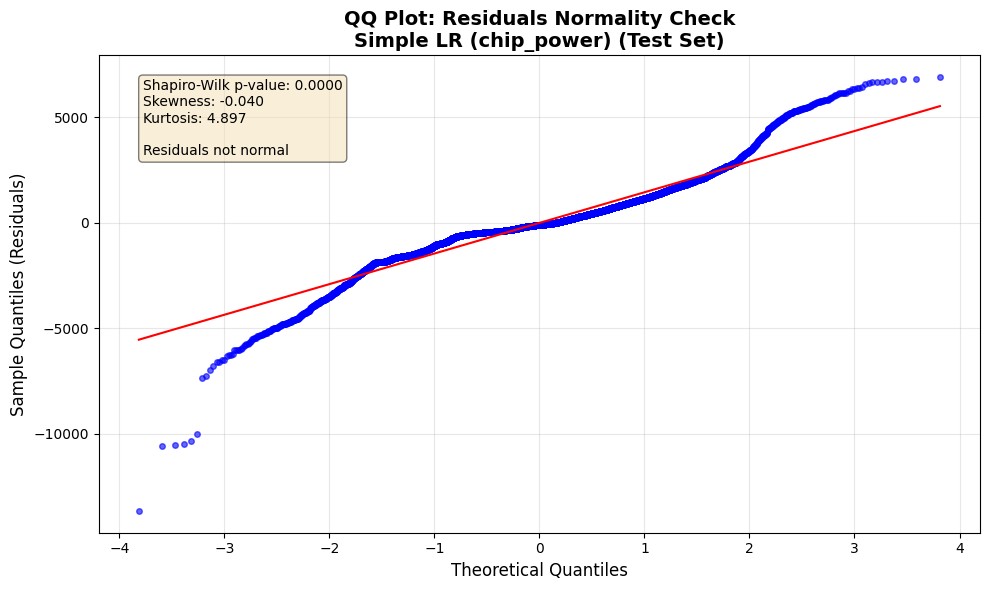

  ✓ Saved: predicted_vs_actual_simple_lr_chip_power.png


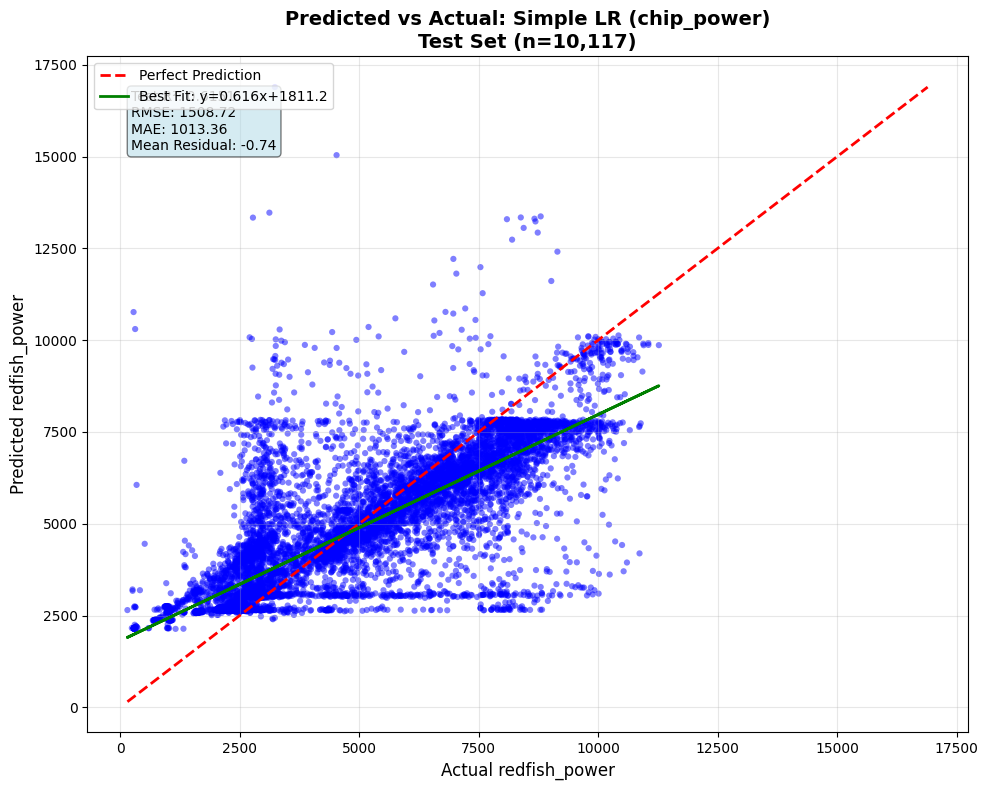

  ✓ Saved: residuals_histogram_simple_lr_chip_power.png


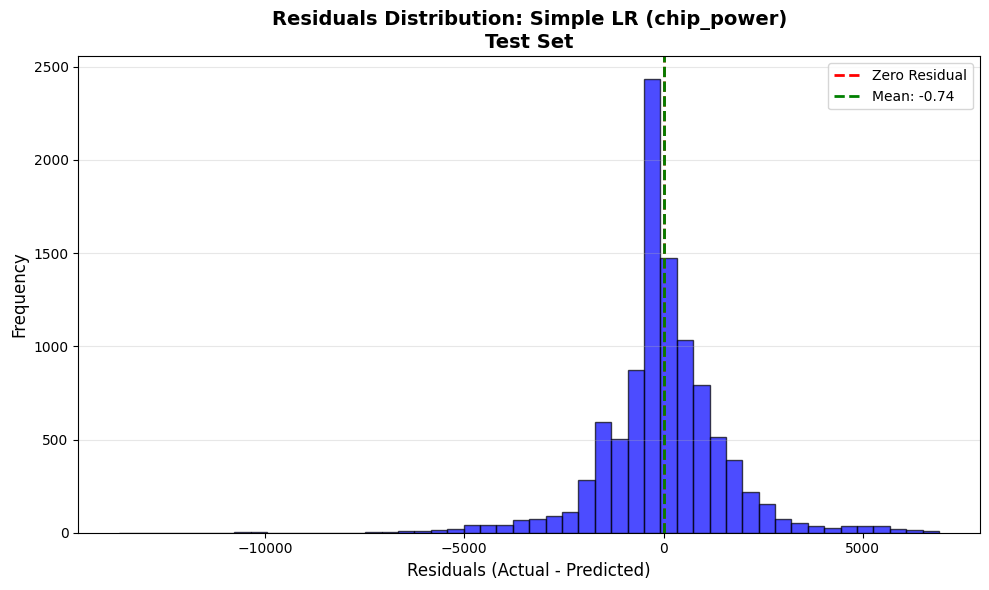


  Residuals Mean: -0.74 (should be ~0)
  Residuals Std: 1508.72
  Residuals Range: [-13652.94, 6911.36]
  Normality (Shapiro-Wilk p-value): 0.0000
    → Residuals may not be normally distributed

Model: Ridge (all features) (Test R²: 0.6768)
Plotting 9,940 sampled points from test set
  ✓ Saved: qq_plot_ridge_all_features.png


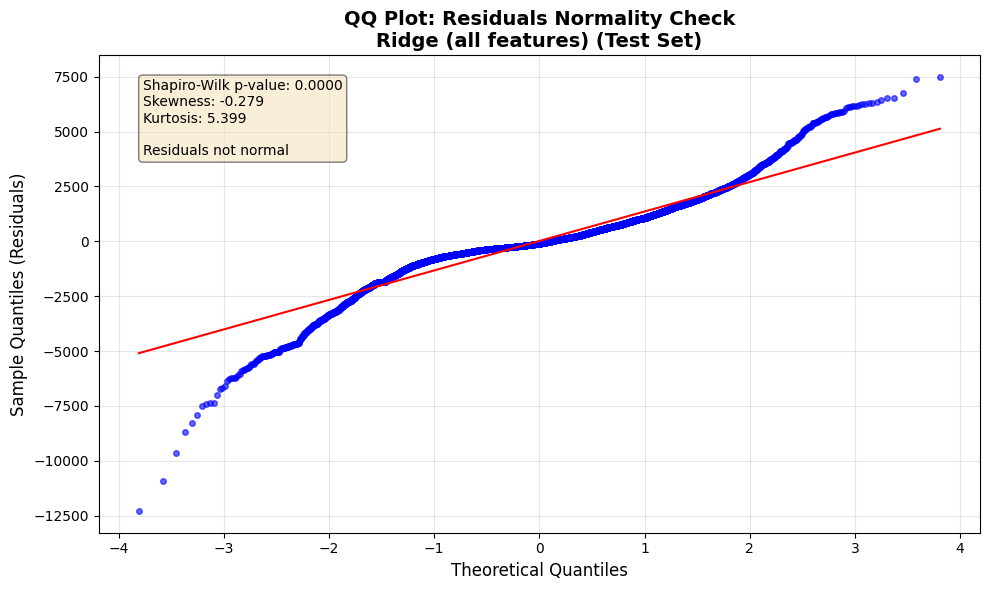

  ✓ Saved: predicted_vs_actual_ridge_all_features.png


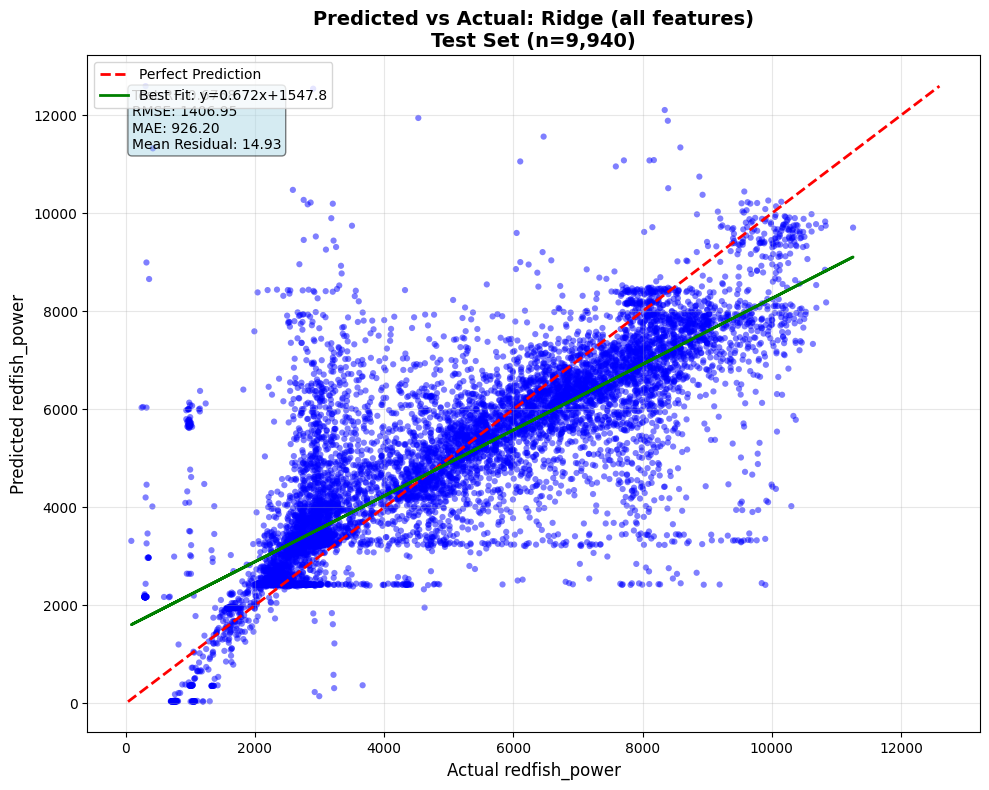

  ✓ Saved: residuals_histogram_ridge_all_features.png


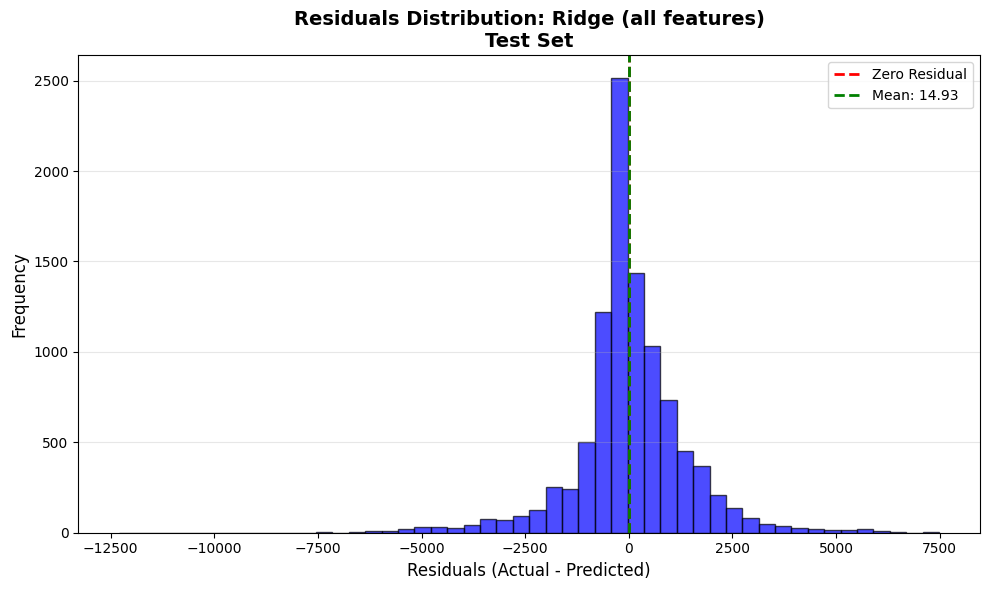


  Residuals Mean: 14.93 (should be ~0)
  Residuals Std: 1406.87
  Residuals Range: [-12289.60, 7483.58]
  Normality (Shapiro-Wilk p-value): 0.0000
    → Residuals may not be normally distributed

Model: Gradient Boosting (Test R²: 0.7400)
Plotting 10,033 sampled points from test set
  ✓ Saved: qq_plot_gradient_boosting.png


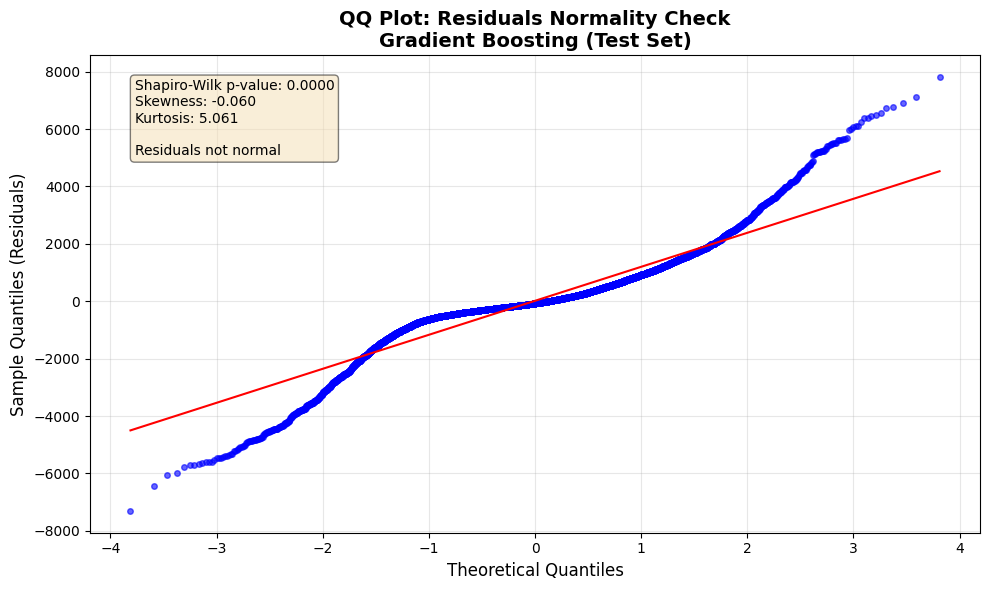

  ✓ Saved: predicted_vs_actual_gradient_boosting.png


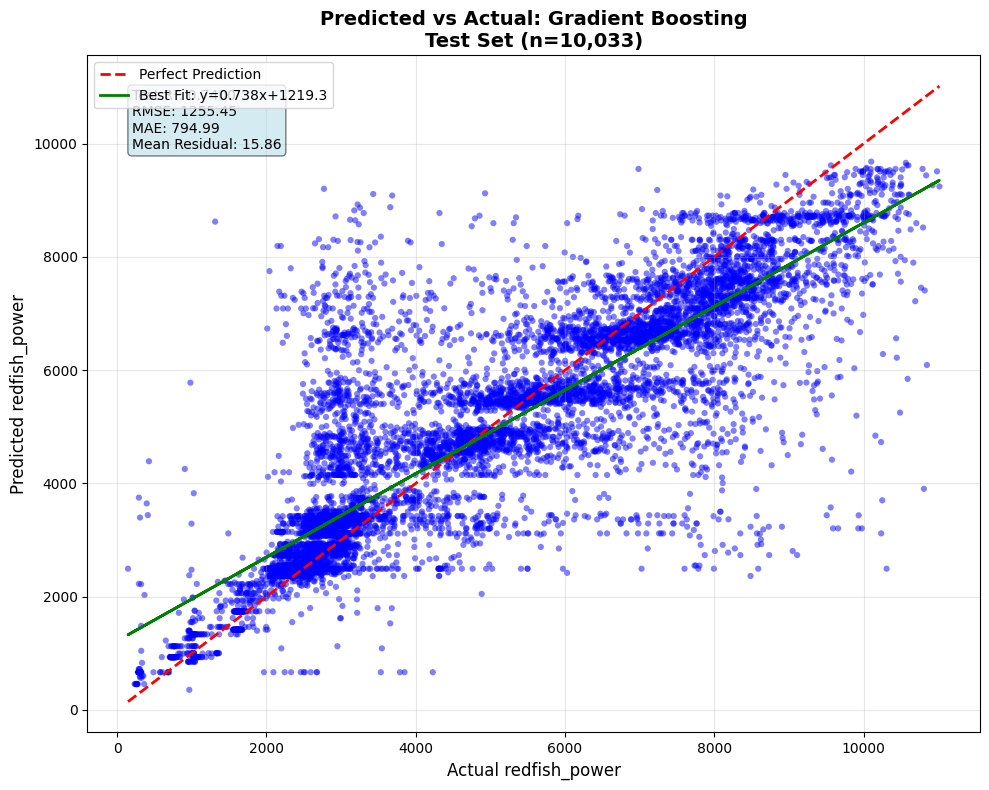

  ✓ Saved: residuals_histogram_gradient_boosting.png


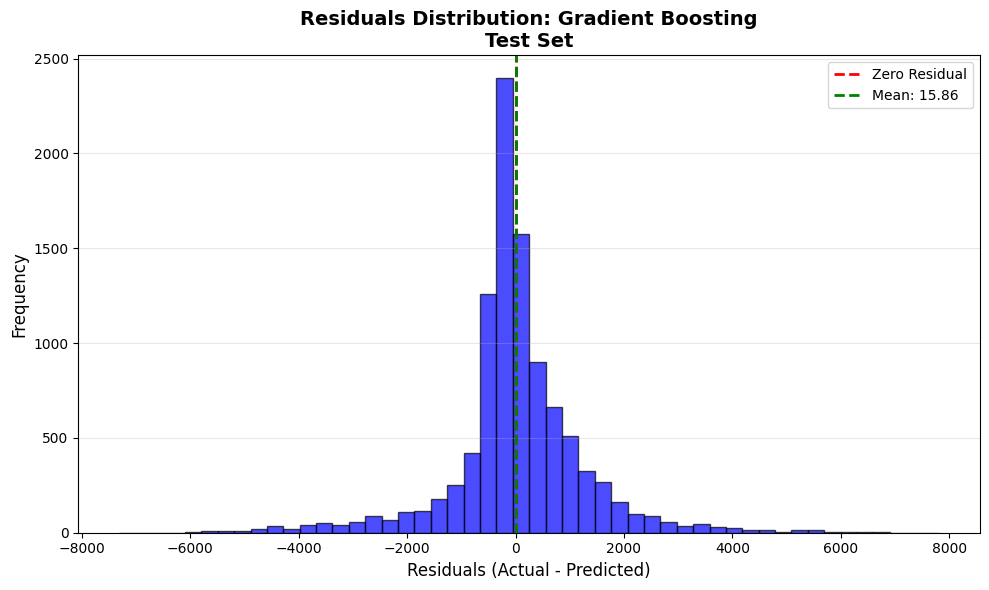


  Residuals Mean: 15.86 (should be ~0)
  Residuals Std: 1255.35
  Residuals Range: [-7310.06, 7813.96]
  Normality (Shapiro-Wilk p-value): 0.0000
    → Residuals may not be normally distributed

Model: Random Forest (Test R²: 0.7462)
Plotting 10,190 sampled points from test set
  ✓ Saved: qq_plot_random_forest.png


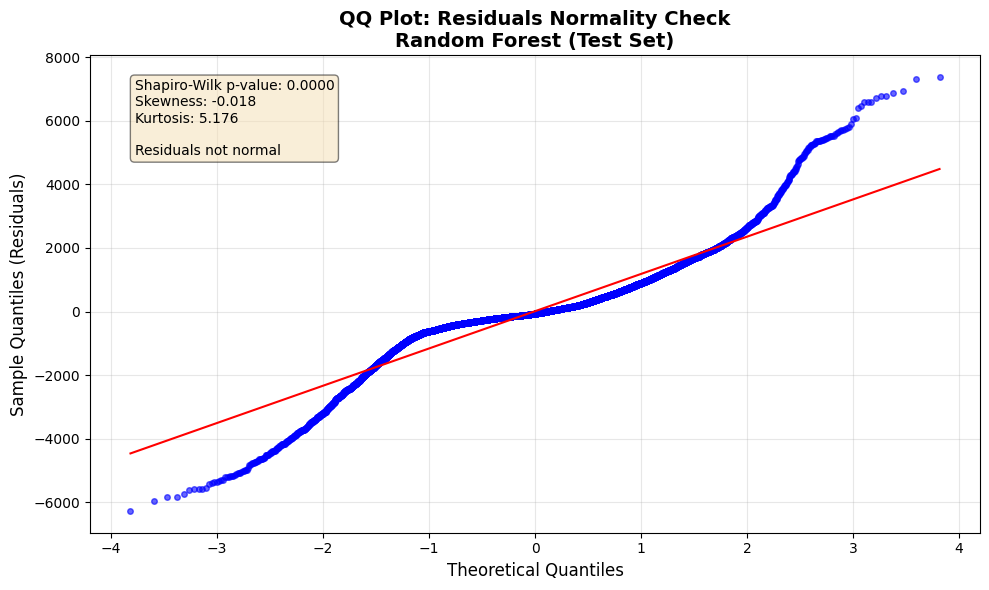

  ✓ Saved: predicted_vs_actual_random_forest.png


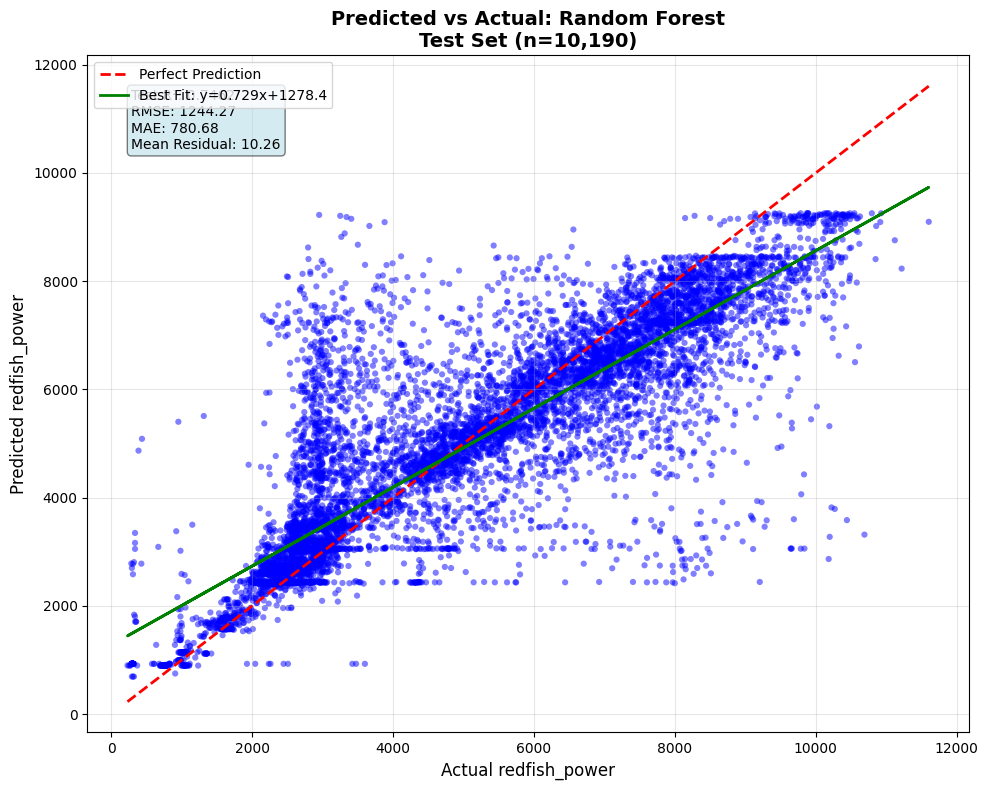

  ✓ Saved: residuals_histogram_random_forest.png


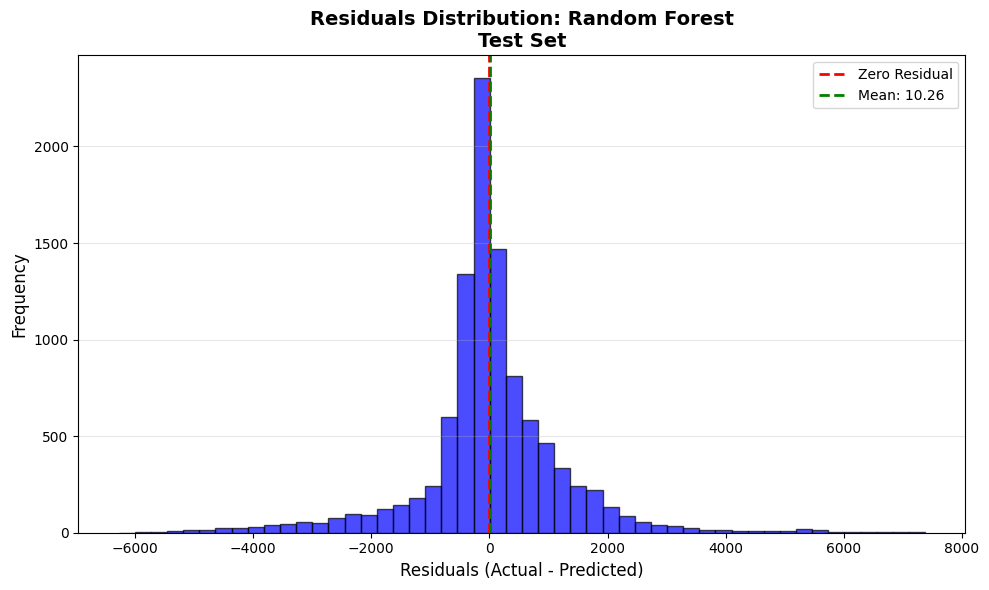


  Residuals Mean: 10.26 (should be ~0)
  Residuals Std: 1244.23
  Residuals Range: [-6273.99, 7375.15]
  Normality (Shapiro-Wilk p-value): 0.0000
    → Residuals may not be normally distributed


GENERATING HTML REPORT

✓ Saved HTML report: model_diagnostics_report.html
  Open this file in a web browser to view all diagnostics
ALL DIAGNOSTIC PLOTS COMPLETE

✓ Generated 12 plots total (3 plots × 4 models)
✓ Files saved in current directory

Files created:
  - qq_plot_simple_lr_chip_power.png
  - predicted_vs_actual_simple_lr_chip_power.png
  - residuals_histogram_simple_lr_chip_power.png
  - qq_plot_ridge_all_features.png
  - predicted_vs_actual_ridge_all_features.png
  - residuals_histogram_ridge_all_features.png
  - qq_plot_gradient_boosting.png
  - predicted_vs_actual_gradient_boosting.png
  - residuals_histogram_gradient_boosting.png
  - qq_plot_random_forest.png
  - predicted_vs_actual_random_forest.png
  - residuals_histogram_random_forest.png


In [35]:
# ========================================
# DIAGNOSTIC PLOTS: QQ Plot & Predicted vs Actual (ALL MODELS)
# ========================================
# Visualizes model performance and residual distribution for ALL trained models

# Install visualization packages (SparkCaster kernel workaround)
import subprocess
import sys
import importlib
import site

def install_and_import(package_name, import_name=None):
    """Install package and reload site-packages to make it importable"""
    if import_name is None:
        import_name = package_name
    
    try:
        return __import__(import_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([
            sys.executable, '-m', 'pip', 'install', 
            '--user', '--upgrade', package_name
        ])
        # Reload site packages to pick up newly installed packages
        importlib.reload(site)
        # Force reimport of sys.path
        import site as site_module
        site_module.main()
        return __import__(import_name)

# Install required packages
install_and_import('matplotlib')
install_and_import('scipy')

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

print("="*60)
print("GENERATING DIAGNOSTIC PLOTS FOR ALL MODELS")
print("="*60)

# ========================================
# Sample data for visualization (use test set)
# ========================================
# Don't plot all rows - sample for performance
PLOT_SAMPLE_SIZE = 10000  # Plot 10k points max

# Define all models to plot
models_to_plot = [
    ('Simple LR (chip_power)', simple_lr_test_pred, simple_lr_test_r2),
    ('Ridge (all features)', ridge_test_pred, ridge_test_r2),
    ('Gradient Boosting', gbt_test_pred, gbt_test_r2),
    ('Random Forest', rf_test_pred, rf_test_r2)
]

# ========================================
# Generate plots for each model
# ========================================
for model_name, test_pred_sdf, test_r2 in models_to_plot:
    print(f"\n{'='*60}")
    print(f"Model: {model_name} (Test R²: {test_r2:.4f})")
    print('='*60)
    
    # Sample and convert to pandas for plotting
    test_sample = test_pred_sdf.select(target_col, "prediction") \
        .sample(False, min(1.0, PLOT_SAMPLE_SIZE / test_count)) \
        .toPandas()
    
    actuals = test_sample[target_col].values
    predictions = test_sample['prediction'].values
    residuals = actuals - predictions
    
    print(f"Plotting {len(actuals):,} sampled points from test set")
    
    # Create filename-safe model name
    filename_safe = model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()
    
    # ========================================
    # Figure 1: QQ Plot (Residuals Normality Check)
    # ========================================
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    
    # Create QQ plot
    stats.probplot(residuals, dist="norm", plot=ax1)
    
    ax1.set_title(f'QQ Plot: Residuals Normality Check\n{model_name} (Test Set)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Theoretical Quantiles', fontsize=12)
    ax1.set_ylabel('Sample Quantiles (Residuals)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Style the points
    ax1.get_lines()[0].set_markerfacecolor('blue')
    ax1.get_lines()[0].set_markeredgecolor('blue')
    ax1.get_lines()[0].set_markersize(4)
    ax1.get_lines()[0].set_alpha(0.6)
    
    # Calculate normality statistics
    _, p_value = stats.shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)
    skewness = stats.skew(residuals)
    kurtosis = stats.kurtosis(residuals)
    
    # Add statistics text box
    stats_text = f'Shapiro-Wilk p-value: {p_value:.4f}\n'
    stats_text += f'Skewness: {skewness:.3f}\n'
    stats_text += f'Kurtosis: {kurtosis:.3f}\n'
    stats_text += f'\nResiduals ~ Normal' if p_value > 0.05 else f'\nResiduals not normal'
    
    ax1.text(0.05, 0.95, stats_text,
             transform=ax1.transAxes,
             fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    filename = f'qq_plot_{filename_safe}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {filename}")
    plt.show()
    
    # ========================================
    # Figure 2: Predicted vs Actual Scatter Plot
    # ========================================
    fig2, ax2 = plt.subplots(figsize=(10, 8))
    
    # Scatter plot with alpha for overlap visualization
    ax2.scatter(actuals, predictions, alpha=0.5, s=20, c='blue', edgecolors='none')
    
    # Perfect prediction line (45-degree)
    min_val = min(actuals.min(), predictions.min())
    max_val = max(actuals.max(), predictions.max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    # Add best fit line
    z = np.polyfit(actuals, predictions, 1)
    p = np.poly1d(z)
    ax2.plot(actuals, p(actuals), "g-", linewidth=2, label=f'Best Fit: y={z[0]:.3f}x+{z[1]:.1f}')
    
    ax2.set_xlabel(f'Actual {target_col}', fontsize=12)
    ax2.set_ylabel(f'Predicted {target_col}', fontsize=12)
    ax2.set_title(f'Predicted vs Actual: {model_name}\nTest Set (n={len(actuals):,})', 
                  fontsize=14, fontweight='bold')
    ax2.legend(loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Add metrics text box
    metrics_text = f'Test R²: {test_r2:.4f}\n'
    metrics_text += f'RMSE: {np.sqrt(np.mean(residuals**2)):.2f}\n'
    metrics_text += f'MAE: {np.mean(np.abs(residuals)):.2f}\n'
    metrics_text += f'Mean Residual: {np.mean(residuals):.2f}'
    
    ax2.text(0.05, 0.95, metrics_text,
             transform=ax2.transAxes,
             fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    plt.tight_layout()
    filename = f'predicted_vs_actual_{filename_safe}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {filename}")
    plt.show()
    
    # ========================================
    # Figure 3: Residuals Histogram
    # ========================================
    fig3, ax3 = plt.subplots(figsize=(10, 6))
    
    ax3.hist(residuals, bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax3.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
    ax3.axvline(np.mean(residuals), color='green', linestyle='--', linewidth=2, label=f'Mean: {np.mean(residuals):.2f}')
    
    ax3.set_xlabel('Residuals (Actual - Predicted)', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title(f'Residuals Distribution: {model_name}\nTest Set', 
                  fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    filename = f'residuals_histogram_{filename_safe}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {filename}")
    plt.show()
    
    # Print diagnostic summary for this model
    print(f"\n  Residuals Mean: {np.mean(residuals):.2f} (should be ~0)")
    print(f"  Residuals Std: {np.std(residuals):.2f}")
    print(f"  Residuals Range: [{residuals.min():.2f}, {residuals.max():.2f}]")
    print(f"  Normality (Shapiro-Wilk p-value): {p_value:.4f}")
    if p_value > 0.05:
        print("    → Residuals appear normally distributed ✓")
    else:
        print("    → Residuals may not be normally distributed")

print("\n" + "="*60)

# ========================================
# Generate Combined HTML Report
# ========================================
print("\n" + "="*60)
print("GENERATING HTML REPORT")
print("="*60)

html_content = '''<!DOCTYPE html>
<html>
<head>
    <title>Model Diagnostic Report - GPU Metrics Prediction</title>
    <style>
        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            margin: 40px;
            background-color: #f5f5f5;
        }
        h1 {
            color: #2c3e50;
            border-bottom: 3px solid #3498db;
            padding-bottom: 10px;
        }
        h2 {
            color: #34495e;
            margin-top: 40px;
            background-color: #ecf0f1;
            padding: 10px;
            border-left: 5px solid #3498db;
        }
        .model-section {
            background-color: white;
            padding: 20px;
            margin: 20px 0;
            border-radius: 8px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        }
        .metrics {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 15px;
            margin: 20px 0;
        }
        .metric-card {
            background-color: #ecf0f1;
            padding: 15px;
            border-radius: 5px;
            text-align: center;
        }
        .metric-label {
            font-size: 12px;
            color: #7f8c8d;
            text-transform: uppercase;
        }
        .metric-value {
            font-size: 24px;
            font-weight: bold;
            color: #2c3e50;
            margin-top: 5px;
        }
        .plot-grid {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(400px, 1fr));
            gap: 20px;
            margin: 20px 0;
        }
        .plot-container {
            text-align: center;
        }
        .plot-container img {
            max-width: 100%;
            border: 1px solid #ddd;
            border-radius: 5px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        }
        .plot-title {
            font-weight: bold;
            margin: 10px 0;
            color: #34495e;
        }
        .best-model {
            background-color: #d5f4e6;
            border-left: 5px solid #27ae60;
        }
        .summary-table {
            width: 100%;
            border-collapse: collapse;
            margin: 20px 0;
            background-color: white;
        }
        .summary-table th {
            background-color: #3498db;
            color: white;
            padding: 12px;
            text-align: left;
        }
        .summary-table td {
            padding: 10px;
            border-bottom: 1px solid #ddd;
        }
        .summary-table tr:hover {
            background-color: #f5f5f5;
        }
        .best-row {
            background-color: #d5f4e6 !important;
            font-weight: bold;
        }
    </style>
</head>
<body>
    <h1>🔍 Model Diagnostic Report: GPU Metrics Prediction</h1>
    <p><strong>Target Variable:</strong> redfish_power</p>
    <p><strong>Features:</strong> tensor_util, gpu_util, tensor_tflops, chip_power</p>
    <p><strong>Generated:</strong> ''' + time.strftime('%Y-%m-%d %H:%M:%S') + '''</p>
    
    <h2>📊 Model Performance Summary</h2>
    <table class="summary-table">
        <thead>
            <tr>
                <th>Model</th>
                <th>CV R² (avg)</th>
                <th>Test R²</th>
                <th>Test RMSE</th>
                <th>Test MAE</th>
            </tr>
        </thead>
        <tbody>
'''

# Add each model's summary
models_summary = [
    ('Simple LR (chip_power)', simple_lr_cv_r2, simple_lr_test_r2, simple_lr_test_rmse, simple_lr_test_mae),
    ('Ridge (all features)', ridge_cv_r2, ridge_test_r2, ridge_test_rmse, ridge_test_mae),
    ('Gradient Boosting', gbt_cv_r2, gbt_test_r2, gbt_test_rmse, gbt_test_mae),
    ('Random Forest', rf_cv_r2, rf_test_r2, rf_test_rmse, rf_test_mae)
]

best_cv_r2_value = max([m[1] for m in models_summary])

for model_name, cv_r2, test_r2, test_rmse, test_mae in models_summary:
    row_class = 'best-row' if cv_r2 == best_cv_r2_value else ''
    html_content += f'''            <tr class="{row_class}">
                <td>{model_name}</td>
                <td>{cv_r2:.4f}</td>
                <td>{test_r2:.4f}</td>
                <td>{test_rmse:.2f}</td>
                <td>{test_mae:.2f}</td>
            </tr>
'''

html_content += '''        </tbody>
    </table>
'''

# Add detailed sections for each model
for model_name, test_pred_sdf, test_r2 in models_to_plot:
    # Determine if this is the best model
    is_best = test_r2 == max([m[2] for m in models_to_plot])
    section_class = 'model-section best-model' if is_best else 'model-section'
    best_badge = ' 🏆 BEST MODEL' if is_best else ''
    
    # Create filename-safe model name
    filename_safe = model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()
    
    # Get model-specific metrics
    if model_name == 'Simple LR (chip_power)':
        cv_r2, test_rmse, test_mae = simple_lr_cv_r2, simple_lr_test_rmse, simple_lr_test_mae
    elif model_name == 'Ridge (all features)':
        cv_r2, test_rmse, test_mae = ridge_cv_r2, ridge_test_rmse, ridge_test_mae
    elif model_name == 'Gradient Boosting':
        cv_r2, test_rmse, test_mae = gbt_cv_r2, gbt_test_rmse, gbt_test_mae
    else:  # Random Forest
        cv_r2, test_rmse, test_mae = rf_cv_r2, rf_test_rmse, rf_test_mae
    
    html_content += f'''
    <div class="{section_class}">
        <h2>{model_name}{best_badge}</h2>
        
        <div class="metrics">
            <div class="metric-card">
                <div class="metric-label">CV R² (5-fold)</div>
                <div class="metric-value">{cv_r2:.4f}</div>
            </div>
            <div class="metric-card">
                <div class="metric-label">Test R²</div>
                <div class="metric-value">{test_r2:.4f}</div>
            </div>
            <div class="metric-card">
                <div class="metric-label">Test RMSE</div>
                <div class="metric-value">{test_rmse:.2f}</div>
            </div>
            <div class="metric-card">
                <div class="metric-label">Test MAE</div>
                <div class="metric-value">{test_mae:.2f}</div>
            </div>
        </div>
        
        <div class="plot-grid">
            <div class="plot-container">
                <div class="plot-title">QQ Plot (Residuals Normality)</div>
                <img src="qq_plot_{filename_safe}.png" alt="QQ Plot">
            </div>
            <div class="plot-container">
                <div class="plot-title">Predicted vs Actual</div>
                <img src="predicted_vs_actual_{filename_safe}.png" alt="Predicted vs Actual">
            </div>
            <div class="plot-container">
                <div class="plot-title">Residuals Distribution</div>
                <img src="residuals_histogram_{filename_safe}.png" alt="Residuals Histogram">
            </div>
        </div>
    </div>
'''

html_content += '''
    <div class="model-section">
        <h2>📝 Notes</h2>
        <ul>
            <li><strong>CV R²:</strong> Average R² across 5-fold cross-validation (training performance estimate)</li>
            <li><strong>Test R²:</strong> R² on held-out test set (true generalization performance)</li>
            <li><strong>QQ Plot:</strong> Points should follow the red line if residuals are normally distributed</li>
            <li><strong>Predicted vs Actual:</strong> Points should cluster around the red diagonal line</li>
            <li><strong>Residuals:</strong> Should be centered around zero with symmetric distribution</li>
        </ul>
    </div>
</body>
</html>
'''

# Write HTML file
html_filename = 'model_diagnostics_report.html'
with open(html_filename, 'w') as f:
    f.write(html_content)

print(f"\n✓ Saved HTML report: {html_filename}")
print(f"  Open this file in a web browser to view all diagnostics")

print("ALL DIAGNOSTIC PLOTS COMPLETE")
print("="*60)
print(f"\n✓ Generated 12 plots total (3 plots × 4 models)")
print(f"✓ Files saved in current directory")
print("\nFiles created:")
print("  - qq_plot_simple_lr_chip_power.png")
print("  - predicted_vs_actual_simple_lr_chip_power.png")
print("  - residuals_histogram_simple_lr_chip_power.png")
print("  - qq_plot_ridge_all_features.png")
print("  - predicted_vs_actual_ridge_all_features.png")
print("  - residuals_histogram_ridge_all_features.png")
print("  - qq_plot_gradient_boosting.png")
print("  - predicted_vs_actual_gradient_boosting.png")
print("  - residuals_histogram_gradient_boosting.png")
print("  - qq_plot_random_forest.png")
print("  - predicted_vs_actual_random_forest.png")
print("  - residuals_histogram_random_forest.png")
print("="*60)

In [ ]:
# ========================================
# FINAL TRAINING: Retrain Best Model on 10% Sample
# ========================================
# Takes the best model from cell 11 (based on CV R²) and retrains on larger dataset

import time
from pyspark import StorageLevel
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler as MLStandardScaler
from pyspark.ml.regression import LinearRegression as MLLinearRegression, GBTRegressor, RandomForestRegressor as MLRandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql import functions as F

print("="*60)
print("FINAL TRAINING ON 10% SAMPLE")
print("="*60)

# ========================================
# CONFIGURATION - Larger Sample
# ========================================
FINAL_SAMPLE_FRAC = 0.10  # 10% sample for final training
SEED = 42
NUM_FOLDS = 5  # Keep 5-fold CV for consistency

feature_cols = [c for c in num_cols if c != "redfish_power"]
target_col = "redfish_power"

print(f"\nBest Model from previous run: {best_model_name}")
print(f"Previous CV R²: {best_cv_r2:.4f}")
print(f"Increasing sample from 2% to {FINAL_SAMPLE_FRAC*100:.0f}%...")

# ========================================
# Data Preparation - 10% Sample
# ========================================
print("\n[1/4] Preparing 10% sample...")

# Keep only necessary columns early (filter out nulls in target)
base_labeled_final = sdf_num.select(*(feature_cols + [target_col])) \
    .where(F.col(target_col).isNotNull())

# Sample 10%
base_labeled_final = base_labeled_final.sample(False, FINAL_SAMPLE_FRAC, SEED)
print(f"Sampled {FINAL_SAMPLE_FRAC*100:.0f}% of labeled data")

# Split into train/test
train_sdf_final, test_sdf_final = base_labeled_final.randomSplit([0.7, 0.3], seed=SEED)

# Cache and materialize
train_sdf_final.cache()
test_sdf_final.cache()

train_count_final = train_sdf_final.count()
test_count_final = test_sdf_final.count()

print(f"Training set: {train_count_final:,} rows (cached)")
print(f"Test set: {test_count_final:,} rows (cached)")

# ========================================
# Feature Assembly
# ========================================
print("\n[2/4] Assembling features...")

assembler_final = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw"
)

assembled_train_final = assembler_final.transform(train_sdf_final) \
    .select("features_raw", target_col)
assembled_train_final.cache()

assembled_test_final = assembler_final.transform(test_sdf_final) \
    .select("features_raw", target_col)
assembled_test_final.cache()

_ = assembled_train_final.count()
_ = assembled_test_final.count()

print("✓ Features assembled and cached")

# ========================================
# Retrain Best Model
# ========================================
print(f"\n[3/4] Retraining {best_model_name} on 10% sample with 5-fold CV...")

# Create evaluator
evaluator_final = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")

# Determine which model to retrain based on best_model_name
if best_model_name == 'Simple LR (chip_power)':
    assembler_chip_final = VectorAssembler(
        inputCols=["chip_power"],
        outputCol="features_chip"
    )
    
    simple_lr_final = MLLinearRegression(
        featuresCol="features_chip",
        labelCol=target_col,
        predictionCol="prediction",
        maxIter=100,
        regParam=0.0,
        elasticNetParam=0.0,
        standardization=False
    )
    
    pipeline_final = Pipeline(stages=[assembler_chip_final, simple_lr_final])
    train_data_final = train_sdf_final
    test_data_final = test_sdf_final

elif best_model_name == 'Ridge (all features)':
    scaler_final = MLStandardScaler(
        inputCol="features_raw",
        outputCol="features_scaled",
        withStd=True,
        withMean=False
    )
    
    ridge_lr_final = MLLinearRegression(
        featuresCol="features_raw",
        labelCol=target_col,
        predictionCol="prediction",
        maxIter=100,
        regParam=1.0,
        elasticNetParam=0.0,
        standardization=False
    )
    
    pipeline_final = Pipeline(stages=[scaler_final, ridge_lr_final])
    train_data_final = assembled_train_final
    test_data_final = assembled_test_final

elif best_model_name == 'Gradient Boosting':
    gbt_final = GBTRegressor(
        featuresCol="features_raw",
        labelCol=target_col,
        predictionCol="prediction",
        maxIter=30,
        maxDepth=4,
        maxBins=32,
        stepSize=0.1,
        subsamplingRate=0.6,
        minInstancesPerNode=100,
        seed=SEED
    )
    pipeline_final = gbt_final
    train_data_final = assembled_train_final
    test_data_final = assembled_test_final

else:  # Random Forest
    rf_final = MLRandomForestRegressor(
        featuresCol="features_raw",
        labelCol=target_col,
        predictionCol="prediction",
        numTrees=30,
        maxDepth=8,
        featureSubsetStrategy="sqrt",
        minInstancesPerNode=50,
        subsamplingRate=0.7,
        seed=SEED
    )
    pipeline_final = rf_final
    train_data_final = assembled_train_final
    test_data_final = assembled_test_final

# Create CrossValidator
param_grid_final = ParamGridBuilder().build()

cv_final = CrossValidator(
    estimator=pipeline_final,
    estimatorParamMaps=param_grid_final,
    evaluator=evaluator_final,
    numFolds=NUM_FOLDS,
    seed=SEED,
    parallelism=4
)

# Train
final_start = time.time()
cv_model_final = cv_final.fit(train_data_final)
final_time = time.time() - final_start

# Get metrics
final_model = cv_model_final.bestModel
final_cv_r2 = cv_model_final.avgMetrics[0]

# Evaluate on train/test
final_train_pred = final_model.transform(train_data_final)
final_test_pred = final_model.transform(test_data_final)

evaluator_r2_final = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")
evaluator_rmse_final = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse")
evaluator_mae_final = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="mae")

final_train_r2 = evaluator_r2_final.evaluate(final_train_pred)
final_train_rmse = evaluator_rmse_final.evaluate(final_train_pred)
final_train_mae = evaluator_mae_final.evaluate(final_train_pred)
final_test_r2 = evaluator_r2_final.evaluate(final_test_pred)
final_test_rmse = evaluator_rmse_final.evaluate(final_test_pred)
final_test_mae = evaluator_mae_final.evaluate(final_test_pred)

print(f"\n  CV R² (avg): {final_cv_r2:.4f}")
print(f"  Training   → R²: {final_train_r2:.4f} | RMSE: {final_train_rmse:.2f} | MAE: {final_train_mae:.2f}")
print(f"  Test       → R²: {final_test_r2:.4f} | RMSE: {final_test_rmse:.2f} | MAE: {final_test_mae:.2f}")
print(f"  Training time: {final_time:.2f}s")

# Show feature importance for tree models
if best_model_name in ['Gradient Boosting', 'Random Forest']:
    feature_importance_final = list(zip(feature_cols, final_model.featureImportances.toArray()))
    feature_importance_final.sort(key=lambda x: x[1], reverse=True)
    print(f"\n  Feature Importance:")
    for feat, imp in feature_importance_final:
        print(f"    {feat}: {imp:.4f}")

# ========================================
# Comparison with 2% Sample
# ========================================
print("\n[4/4] Comparison: 2% vs 10% Sample")
print("="*60)

import pandas as pd
comparison_final = pd.DataFrame({
    'Metric': ['Sample Size', 'Training Rows', 'Test Rows', 'CV R² (avg)', 'Test R²', 'Test RMSE', 'Test MAE', 'Training Time (s)'],
    '2% Sample': [
        '2%',
        f'{train_count:,}',
        f'{test_count:,}',
        f'{best_cv_r2:.4f}',
        f'{best_test_r2:.4f}',
        'N/A',  # Not saved from previous run
        'N/A',
        'N/A'
    ],
    '10% Sample': [
        '10%',
        f'{train_count_final:,}',
        f'{test_count_final:,}',
        f'{final_cv_r2:.4f}',
        f'{final_test_r2:.4f}',
        f'{final_test_rmse:.2f}',
        f'{final_test_mae:.2f}',
        f'{final_time:.2f}'
    ]
})
print(comparison_final.to_string(index=False))

improvement = final_test_r2 - best_test_r2
print(f"\n✓ Test R² improvement: {improvement:+.4f} ({improvement/best_test_r2*100:+.1f}%)")

# ========================================
# Save Final Model (Optional)
# ========================================
print("\n" + "="*60)
print("FINAL MODEL SUMMARY")
print("="*60)
print(f"Model: {best_model_name}")
print(f"Training Data: {train_count_final:,} rows (10% of labeled data)")
print(f"CV R²: {final_cv_r2:.4f}")
print(f"Test R²: {final_test_r2:.4f}")
print(f"Test RMSE: {final_test_rmse:.2f}")
print(f"Test MAE: {final_test_mae:.2f}")
print("="*60)

print("\n💾 To save this model for production use:")
print("   final_model.write().overwrite().save('/path/to/model')")

# Clean up
assembled_train_final.unpersist()
assembled_test_final.unpersist()
train_sdf_final.unpersist()
test_sdf_final.unpersist()

print("\n✓ Final training complete and memory released")

FINAL TRAINING ON 10% SAMPLE

Best Model from previous run: Random Forest
Previous CV R²: 0.7462
Increasing sample from 2% to 10%...

[1/4] Preparing 10% sample...
Sampled 10% of labeled data
Training set: 21,351,733 rows (cached)
Test set: 9,149,913 rows (cached)

[2/4] Assembling features...
✓ Features assembled and cached

[3/4] Retraining Random Forest on 10% sample with 5-fold CV...

  CV R² (avg): 0.7465
  Training   → R²: 0.7467 | RMSE: 1241.84 | MAE: 776.86
  Test       → R²: 0.7470 | RMSE: 1241.11 | MAE: 776.43
  Training time: 247.37s

  Feature Importance:
    chip_power: 0.2800
    tensor_tflops_sm: 0.2204
    tensor_tflops: 0.1544
    sm_active: 0.1184
    sm_occupancy: 0.0566
    peak_tflops_unit: 0.0346
    tensor_util: 0.0321
    dram_active: 0.0275
    peak_power_unit: 0.0156
    gpu_util: 0.0147
    sm_clock: 0.0137
    vram_usage: 0.0116
    gpu_peak_power_node_watts: 0.0114
    mem_copy_util: 0.0089

[4/4] Comparison: 2% vs 10% Sample
           Metric 2% Sample 10%

In [46]:
# ========================================
# IMPUTE AND WRITE TO NESSIE (OPTIMIZED)
# ========================================
# Efficient approach: Apply imputation directly to original df and write to Nessie
# No intermediate joins or caching needed

import time
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler

print("="*60)
print("OPTIMIZED IMPUTATION AND NESSIE WRITE")
print("="*60)

# Configuration
NESSIE_DATABASE = "sandbox_finance"
NESSIE_TABLE = "dcgm_metrics_raw_impute"
FULL_TABLE_NAME = f"sandbox.{NESSIE_DATABASE}.{NESSIE_TABLE}"

print(f"\nTarget table: {FULL_TABLE_NAME}")
print(f"Model: {best_model_name}")

# Step 1: Check original data
print("\n[1/4] Checking original data...")
total_rows = df.count()
null_count_before = df.filter(F.col(target_col).isNull()).count()
print(f"Total rows: {total_rows:,}")
print(f"Rows with NULL {target_col}: {null_count_before:,} ({100*null_count_before/total_rows:.1f}%)")

# Step 2: Assemble features for prediction
print("\n[2/4] Assembling features...")
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw",
    handleInvalid="keep"  # Keep rows with null features, we'll handle them
)

df_with_features = assembler.transform(df)
print("✓ Features assembled")

# Step 3: Apply model to generate predictions
print("\n[3/4] Generating predictions for all rows...")
print("Note: Model will predict for all rows, but we'll only use predictions where redfish_power is NULL")

df_with_predictions = final_model.transform(df_with_features)
print("✓ Predictions generated")

# Step 4: Create final imputed column - use prediction only where original is NULL
print("\n[4/4] Creating imputed dataset...")
df_imputed = df_with_predictions.withColumn(
    target_col,
    F.when(F.col(target_col).isNull(), F.col("prediction"))
      .otherwise(F.col(target_col))
)

# Clean up: drop temporary columns
columns_to_drop = ["features_raw", "prediction", "_row_id"]
for col in columns_to_drop:
    if col in df_imputed.columns:
        df_imputed = df_imputed.drop(col)

print("✓ Imputation complete")

# Verify imputation
null_count_after = df_imputed.filter(F.col(target_col).isNull()).count()
imputed_count = null_count_before - null_count_after
print(f"\nImputation results:")
print(f"  Original NULLs: {null_count_before:,}")
print(f"  Remaining NULLs: {null_count_after:,}")
print(f"  Successfully imputed: {imputed_count:,}")

if null_count_after > 0:
    print(f"  ⚠️ {null_count_after:,} rows still NULL (likely had NULL features)")

# Show schema
print(f"\nFinal schema: {len(df_imputed.columns)} columns")
print("Sample columns:", df_imputed.columns[:10])

# Show sample
print("\nSample imputed data:")
df_imputed.select("datestamp", "node", target_col, "chip_power").show(5)

# Configure S3 credentials for Iceberg write (SparkCaster requirement)
# print("\nConfiguring S3 credentials for Iceberg write...")
# spark.conf.set("spark.hadoop.fs.s3a.access.key", caios_access_key)
# spark.conf.set("spark.hadoop.fs.s3a.secret.key", caios_secret_key)
# spark.conf.set("spark.hadoop.fs.s3a.endpoint", "object.ord1.coreweave.com")
# spark.conf.set("spark.hadoop.fs.s3a.path.style.access", "true")
# spark.conf.set("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
# print("✓ S3 credentials configured")

# Step 5: Write to Nessie
print("\n" + "="*60)
print("WRITING TO NESSIE")
print("="*60)
print(f"\nWriting {total_rows:,} rows to {FULL_TABLE_NAME}...")
print("This may take several minutes...")

write_start = time.time()

try:
    df_imputed.writeTo(FULL_TABLE_NAME) \
        .using("iceberg") \
        .createOrReplace()
    
    write_time = time.time() - write_start
    
    print(f"\n✓ Write completed successfully!")
    print(f"  Table: {FULL_TABLE_NAME}")
    print(f"  Rows written: {total_rows:,}")
    print(f"  Write time: {write_time:.1f}s ({write_time/60:.1f} minutes)")
    
    # Verify
    print("\nVerifying...")
    verify_df = spark.table(FULL_TABLE_NAME)
    verify_count = verify_df.count()
    verify_nulls = verify_df.filter(F.col(target_col).isNull()).count()
    
    print(f"✓ Verification successful!")
    print(f"  Total rows: {verify_count:,}")
    print(f"  NULL {target_col}: {verify_nulls:,}")
    print(f"  Complete rows: {verify_count - verify_nulls:,}")
    
    print("\n" + "="*60)
    print("IMPUTATION AND WRITE COMPLETE!")
    print("="*60)
    
except Exception as e:
    write_time = time.time() - write_start
    print(f"\n✗ Write failed after {write_time:.1f}s")
    print(f"Error: {e}")
    raise


OPTIMIZED IMPUTATION AND NESSIE WRITE

Target table: sandbox.sandbox_finance.dcgm_metrics_raw_impute
Model: Random Forest

[1/4] Checking original data...
Total rows: 773,519,318
Rows with NULL redfish_power: 439,528,093 (56.8%)

[2/4] Assembling features...
✓ Features assembled

[3/4] Generating predictions for all rows...
Note: Model will predict for all rows, but we'll only use predictions where redfish_power is NULL
✓ Predictions generated

[4/4] Creating imputed dataset...
✓ Imputation complete

Imputation results:
  Original NULLs: 439,528,093
  Remaining NULLs: 0
  Successfully imputed: 439,528,093

Final schema: 38 columns
Sample columns: ['datestamp', 'node', 'gpu_util', 'tensor_util', 'chip_power', 'dram_active', 'mem_copy_util', 'vram_usage', 'sm_active', 'sm_clock']

Sample imputed data:
+-------------------+-------+------------------+-----------------+
|          datestamp|   node|     redfish_power|       chip_power|
+-------------------+-------+------------------+-------

In [10]:
df_check = ness.sql("select * from sandbox.sandbox_finance.dcgm_metrics_raw_impute limit 10")
df_check.show(5,truncate=False)

+-------------------+-------+--------+-------------------+-----------------+-----------+-------------+----------+-------------------+--------+-------------------+------+-----+-------+-----------+------+---------------------+------+------------------+-------------+-----------------+---------------------+-------+----------------+----------------+-----------+------------+------------------+----------------+---------------+---------------+----------------------+--------------------------+-----------------------+----------------------+------------------+------------------+-------------------------+
|datestamp          |node   |gpu_util|tensor_util        |chip_power       |dram_active|mem_copy_util|vram_usage|sm_active          |sm_clock|sm_occupancy       |region|zone |cluster|cluster_org|cw_sku|model                |serial|redfish_power     |customer_name|flag_is_coreweave|model_imputed        |product|product_resolved|customer_segment|is_training|is_multinode|gpu_count_expected|peak_tflo

In [ ]:
#optuna optimization learnings
    #no CV during optimization stage too slow, run without CV then CV on best model only for validation at end
    #testing with increase in datasize 10%, but initial result don't seem too different than 2% also means that the shuffle is good
    #overall result of increasing datasize is reducing r^2 by 1-2% in optuna
    # result of increasing 10% in 
    #ensemble models not expected to provide performance boost, prob because relationships are too simplisitc
    #xgboost would be faster then gbt but not expected to be better fit
    #next step would be to add feature engineering in the form of time lag etc 
    #legacy hyperparamter tuning at 20% show equivalent r^2 at 76% ish
# rerun modeling cells to observe perf improvement from parallelism
# optimize overall for spark perf
# save as sparkcaster baseline